# -------------------: Multimodal Colon Cancer Detection Model :---------------------

# Notebook 1 : Data Loading, EDA & Dataset Preparation

# 1. Import Libraries : 

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Define Dataset Paths : 

In [2]:
VIDEO_XLSX = r"C:\Users\upadh\Downloads\colonVideosWithLabels.xlsx"
PATHO_XLSX = r"C:\Users\upadh\Downloads\pathoImagesWithLabels.xlsx"
IHC_XLSX = r"C:\Users\upadh\Downloads\ihcData.xlsx"

# 3. Load Datasets : 

In [3]:
video_df = pd.read_excel(VIDEO_XLSX)
pathology_df = pd.read_excel(PATHO_XLSX)
ihc_df = pd.read_excel(IHC_XLSX)

print("Video Shape : ", video_df.shape)
print("Pathology Shape : ", pathology_df.shape)
print("IHC Shape : ", ihc_df.shape)

Video Shape :  (133, 17)
Pathology Shape :  (1903, 17)
IHC Shape :  (407, 17)


# 4. Display First Few Rows : 

In [4]:
print("VIDEO DATA")
display(video_df.head())

print("\nPATHOLOGY DATA")
display(pathology_df.head())

print("\nIHC DATA")
display(ihc_df.head())

VIDEO DATA


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,58,colon,patient58,polyp1,M,42.0,rectum,nonneoplastic,hyperplastic,15.0,strong,weak,weak,50.0,1.0,32.0,5.0
1,85,colon,patient85,polyp1,M,83.0,sigmoid,nonneoplastic,hyperplastic,30.0,strong,negative,weak,40.0,1.0,22.0,15.0
2,92,colon,patient92,polyp1,M,61.0,rectum,nonneoplastic,hyperplastic,30.0,strong,negative,weak,10.0,2.0,70.0,10.0
3,109,colon,patient109,polyp1,M,45.0,sigmoid,nonneoplastic,hyperplastic,20.0,strong,negative,weak,40.0,3.0,76.0,10.0
4,108,colon,patient108,polyp1,F,50.0,sigmoid,neoplastic,tubular,40.0,negative,negative,strong,90.0,2.0,70.0,15.0



PATHOLOGY DATA


,ID,imageNames,patho,patient,polyp,location,type,subtype,zooming,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX5,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
1,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,"slideX2,5",10.0,negative,negative,weak,10.0,68.0,2.0,1.0
2,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX20,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
3,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX10,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
4,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX10,15.0,strong,negative,weak,80.0,67.0,2.0,15.0



IHC DATA


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,1,colon,patient1,polyp1,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,20.0,47.0,2.0,15.0
1,1,colon,patient1,polyp2,M,53,descending,nonneoplastic,hyperplastic,40.0,negative,negative,negative,30.0,39.0,2.0,10.0
2,1,colon,patient1,polyp3,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,50.0,50.0,3.0,20.0
3,2,colon,patient2,polyp1,M,49,ascending,nonneoplastic,hyperplastic,50.0,negative,negative,weak,40.0,63.0,3.0,5.0
4,2,colon,patient2,polyp2,M,49,descending,neoplastic,villous,60.0,negative,negative,weak,70.0,57.0,2.0,25.0


# 5. Dataset Information : 

In [5]:
print("="*60)
print("VIDEO INFO")
print("="*60)

video_df.info()

print("\n")

print("="*60)
print("PATHOLOGY INFO")
print("="*60)

pathology_df.info()

print("\n")

print("="*60)
print("IHC INFO")
print("="*60)

ihc_df.info()

VIDEO INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            133 non-null    int64  
 1   colon                         133 non-null    object 
 2   patient                       133 non-null    object 
 3   polyp                         133 non-null    object 
 4   gender                        133 non-null    object 
 5   age                           128 non-null    float64
 6   location                      133 non-null    object 
 7   type                          133 non-null    object 
 8   subtype                       133 non-null    object 
 9   Ki-67(clone30-9)              128 non-null    float64
 10  BRAF(cloneV600E)              129 non-null    object 
 11  PD-L1epithelium(clone SP142)  129 non-null    object 
 12  PD-L1lymphocyte(clone SP142)  129 non-null    object 

# 6. Missing Values : 

In [6]:
print("VIDEO MISSING VALUES")
display(pd.DataFrame({
    "Missing": video_df.isnull().sum(),
    "Percent": video_df.isnull().mean()*100
}))

print("\nPATHOLOGY MISSING VALUES")
display(pd.DataFrame({
    "Missing": pathology_df.isnull().sum(),
    "Percent": pathology_df.isnull().mean()*100
}))

print("\nIHC MISSING VALUES")
display(pd.DataFrame({
    "Missing": ihc_df.isnull().sum(),
    "Percent": ihc_df.isnull().mean()*100
}))

VIDEO MISSING VALUES


,Missing,Percent
ID,0,0.000000
colon,0,0.000000
patient,0,0.000000
polyp,0,0.000000
gender,0,0.000000
age,5,3.759398
location,0,0.000000
type,0,0.000000
subtype,0,0.000000
Ki-67(clone30-9),5,3.759398



PATHOLOGY MISSING VALUES


,Missing,Percent
ID,0,0.000000
imageNames,0,0.000000
patho,0,0.000000
patient,0,0.000000
polyp,0,0.000000
location,0,0.000000
type,0,0.000000
subtype,0,0.000000
zooming,0,0.000000
Ki-67(clone30-9),78,4.098791



IHC MISSING VALUES


,Missing,Percent
ID,0,0.000000
colon,1,0.245700
patient,9,2.211302
polyp,8,1.965602
gender,0,0.000000
age,0,0.000000
location,0,0.000000
type,4,0.982801
subtype,4,0.982801
Ki-67(clone30-9),15,3.685504


# 7. Duplicate Rows : 

In [7]:
print("Video Duplicates : ", video_df.duplicated().sum())
print("Pathology Duplicates : ", pathology_df.duplicated().sum())
print("IHC Duplicates : ", ihc_df.duplicated().sum())

Video Duplicates :  0
Pathology Duplicates :  0
IHC Duplicates :  0


# 8. Unique Patients : 

In [8]:
print("Unique Video Patients : ", video_df["patient"].nunique())
print("Unique Pathology Patients : ", pathology_df["patient"].nunique())
print("Unique IHC Patients : ", ihc_df["patient"].nunique())

Unique Video Patients :  132
Unique Pathology Patients :  198
Unique IHC Patients :  201


# 9. Common Patient Analysis : 

In [9]:
video_patients = set(video_df["patient"].astype(str))
path_patients = set(pathology_df["patient"].astype(str))
ihc_patients = set(ihc_df["patient"].astype(str))

common_patients = (video_patients & path_patients & ihc_patients)

print("Common Patients : ", len(common_patients))
print("Video Only : ", len(video_patients-common_patients))
print("Pathology Only : ", len(path_patients-common_patients))
print("IHC Only : ", len(ihc_patients-common_patients))

Common Patients :  130
Video Only :  2
Pathology Only :  68
IHC Only :  72


# 10. Class Distribution : 

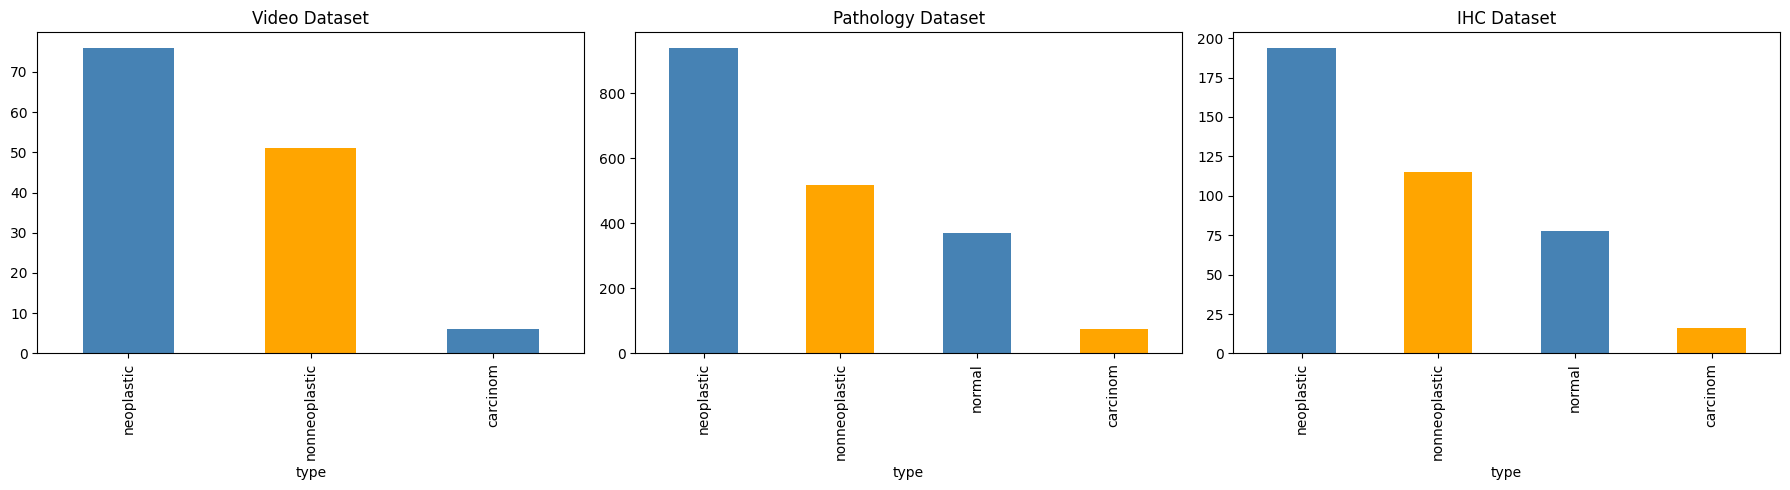

In [10]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

video_df["type"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue","orange"]
)

axes[0].set_title("Video Dataset")

pathology_df["type"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    color=["steelblue","orange"]
)

axes[1].set_title("Pathology Dataset")

ihc_df["type"].value_counts().plot(
    kind="bar",
    ax=axes[2],
    color=["steelblue","orange"]
)

axes[2].set_title("IHC Dataset")

plt.tight_layout()
plt.show()

# 11. Standardize Class Names : 

In [11]:
def clean_type(x) :
    if pd.isna(x) :
        return np.nan

    x = str(x).strip().lower()
    mapping = {
        "nonneoplastic": "nonneoplastic",
        "neoplastic": "neoplastic"
        # "normal": "normal",
        # "carcinom": "carcinom"
    }
    return mapping.get(x, np.nan)

video_df["type"] = video_df["type"].apply(clean_type)
pathology_df["type"] = pathology_df["type"].apply(clean_type)
ihc_df["type"] = ihc_df["type"].apply(clean_type)

In [12]:
print("Before Cleaning")
print("Video:", len(video_df))
print("Pathology:", len(pathology_df))
print("IHC:", len(ihc_df))

video_df = video_df.dropna(subset=["type"]).reset_index(drop=True)
pathology_df = pathology_df.dropna(subset=["type"]).reset_index(drop=True)
ihc_df = ihc_df.dropna(subset=["type"]).reset_index(drop=True)

print("\nAfter Cleaning")
print("Video:", len(video_df))
print("Pathology:", len(pathology_df))
print("IHC:", len(ihc_df))

Before Cleaning
Video: 133
Pathology: 1903
IHC: 407

After Cleaning
Video: 127
Pathology: 1459
IHC: 309


# 12. Verify Classes : 

In [13]:
print(sorted(video_df["type"].unique()))
print(sorted(pathology_df["type"].unique()))
print(sorted(ihc_df["type"].unique()))

['neoplastic', 'nonneoplastic']
['neoplastic', 'nonneoplastic']
['neoplastic', 'nonneoplastic']


In [14]:
ihc_df["type"].value_counts(dropna=False)

type
neoplastic       194
nonneoplastic    115
Name: count, dtype: int64

# 13. Label Encoding : 

In [15]:
all_labels = pd.concat([
    video_df["type"],
    pathology_df["type"],
    ihc_df["type"]
])

label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

print("Classes:")
print(label_encoder.classes_)

Classes:
['neoplastic' 'nonneoplastic']


# 14. Create Label IDs : 

In [16]:
video_df["LabelID"] = label_encoder.transform(video_df["type"])
pathology_df["LabelID"] = label_encoder.transform(pathology_df["type"])
ihc_df["LabelID"] = label_encoder.transform(ihc_df["type"])

# 15. Verify Label Mapping : 

In [17]:
label_mapping = {cls : idx
    for idx, cls in enumerate(label_encoder.classes_)
}

print(label_mapping)

{'neoplastic': 0, 'nonneoplastic': 1}


# 16. Check Encoded Distribution : 

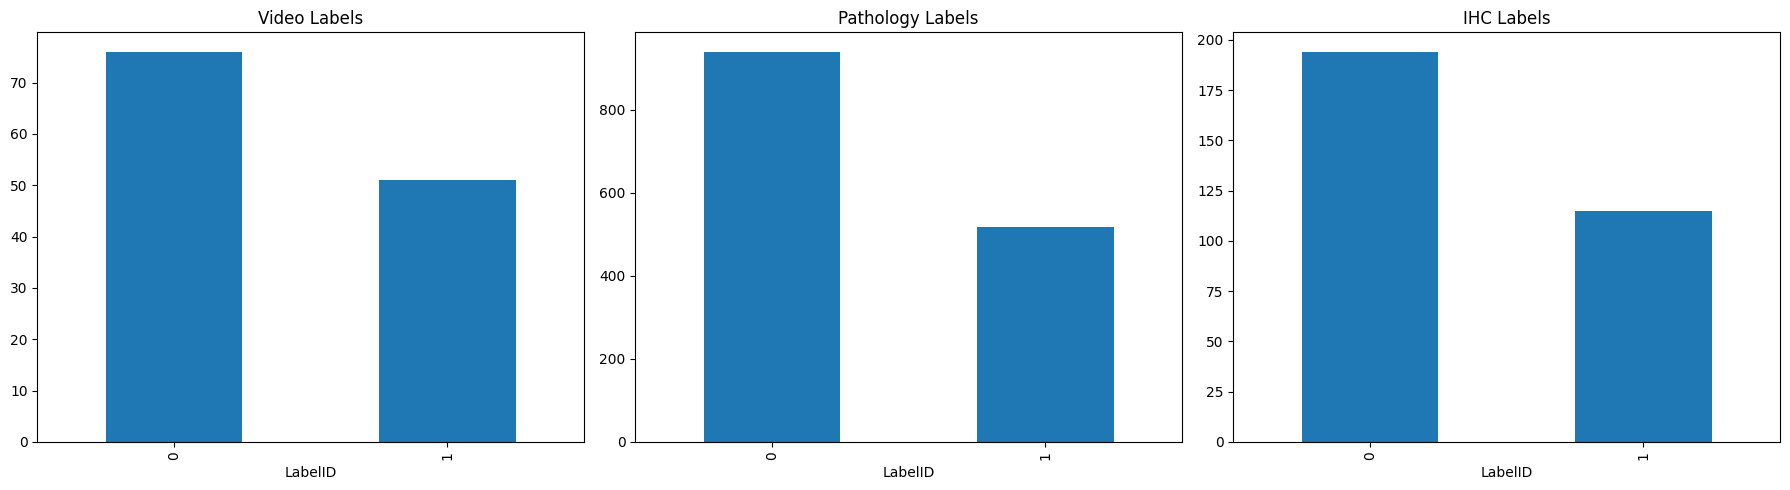

In [18]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

video_df["LabelID"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Video Labels")

pathology_df["LabelID"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Pathology Labels")

ihc_df["LabelID"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("IHC Labels")

plt.tight_layout()
plt.show()

# 17. Save Label Encoder : 

In [19]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    label_encoder,
    "artifacts/label_encoder.pkl"
)

print("Label Encoder Saved")

Label Encoder Saved


# 18. Save Label Mapping CSV : 

In [20]:
mapping_df = pd.DataFrame({
    "ClassName" : label_encoder.classes_,
    "LabelID" : range(len(label_encoder.classes_))
})
mapping_df.to_csv(
    "artifacts/label_mapping.csv",
    index=False
)
mapping_df

,ClassName,LabelID
0,neoplastic,0
1,nonneoplastic,1


# 19. Save Cleaned Data : 

In [21]:
video_df.to_csv("artifacts/video_clean.csv", index=False)
pathology_df.to_csv("artifacts/pathology_clean.csv", index=False)
ihc_df.to_csv("artifacts/ihc_clean.csv", index=False)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


# 20. Final Dataset Summary : 

In [22]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Video Dataset Shape      : {video_df.shape}")
print(f"Pathology Dataset Shape  : {pathology_df.shape}")
print(f"IHC Dataset Shape        : {ihc_df.shape}")

print()

print(f"Common Patients          : {len(common_patients)}")

print()

print("Classes:")
print(label_encoder.classes_)

print()

print("Video Patients      :", video_df["patient"].nunique())
print("Pathology Patients  :", pathology_df["patient"].nunique())
print("IHC Patients        :", ihc_df["patient"].nunique())

DATASET SUMMARY
Video Dataset Shape      : (127, 18)
Pathology Dataset Shape  : (1459, 18)
IHC Dataset Shape        : (309, 18)

Common Patients          : 130

Classes:
['neoplastic' 'nonneoplastic']

Video Patients      : 126
Pathology Patients  : 194
IHC Patients        : 196


# Notebook 2 : Video Frame Extraction (1 FPS)

# 1. Import Libraries : 

In [23]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

# 2. Load Cleaned Video Dataset : 

In [24]:
video_df = pd.read_csv("artifacts/video_clean.csv")
print(video_df.shape)
video_df.head()

(127, 18)


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,58,colon,patient58,polyp1,M,42.0,rectum,nonneoplastic,hyperplastic,15.0,strong,weak,weak,50.0,1.0,32.0,5.0,1
1,85,colon,patient85,polyp1,M,83.0,sigmoid,nonneoplastic,hyperplastic,30.0,strong,negative,weak,40.0,1.0,22.0,15.0,1
2,92,colon,patient92,polyp1,M,61.0,rectum,nonneoplastic,hyperplastic,30.0,strong,negative,weak,10.0,2.0,70.0,10.0,1
3,109,colon,patient109,polyp1,M,45.0,sigmoid,nonneoplastic,hyperplastic,20.0,strong,negative,weak,40.0,3.0,76.0,10.0,1
4,108,colon,patient108,polyp1,F,50.0,sigmoid,neoplastic,tubular,40.0,negative,negative,strong,90.0,2.0,70.0,15.0,0


# 3. Define Video Folder Path : 

In [25]:
VIDEO_FOLDER = r"C:\Users\upadh\Downloads\colonVideosWithLabels"
OUTPUT_FOLDER = r"processed_data\video_frames"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Output Folder Ready")

Output Folder Ready


# 4. Inspect Video Filename Column : 

In [26]:
import os

video_files = [
    f for f in os.listdir(VIDEO_FOLDER)
    if f.endswith(".avi")
]

print("Total AVI Files :", len(video_files))
video_files[:5]

Total AVI Files : 132


['colon-patient10-polyp1-M-83-rectum-neoplastic-tubulovillous-70-negative-negative-weak-50-2-58-50.avi',
 'colon-patient101-polyp1-F-63-sigmoid-neoplastic-tubular-25-negative-negative-weak-20-1-30-10.avi',
 'colon-patient103-polyp1-F-65-rectum-nonneoplastic-hyperplastic-15-kuvvetli-negative-weak-90-2-49-10.avi',
 'colon-patient105-polyp1-M-65-rectum-neoplastic-tubular-40-negative-weak-weak-0-1-39-50.avi',
 'colon-patient106-polyp1-M-67-rectum-neoplastic-tubular-30-negative-weak-weak-80-2-56-25.avi']

# 5. Create Patient To Video Mapping : 

In [27]:
import re

patient_video_map = {}

for file in video_files :
    match = re.search(r"patient(\d+)", file)

    if match :
        patient_id = f"patient{match.group(1)}"
        patient_video_map[patient_id] = file

print("Mapped Patients : ", len(patient_video_map))
list(patient_video_map.items())[:5]

Mapped Patients :  131


[('patient10',
  'colon-patient10-polyp1-M-83-rectum-neoplastic-tubulovillous-70-negative-negative-weak-50-2-58-50.avi'),
 ('patient101',
  'colon-patient101-polyp1-F-63-sigmoid-neoplastic-tubular-25-negative-negative-weak-20-1-30-10.avi'),
 ('patient103',
  'colon-patient103-polyp1-F-65-rectum-nonneoplastic-hyperplastic-15-kuvvetli-negative-weak-90-2-49-10.avi'),
 ('patient105',
  'colon-patient105-polyp1-M-65-rectum-neoplastic-tubular-40-negative-weak-weak-0-1-39-50.avi'),
 ('patient106',
  'colon-patient106-polyp1-M-67-rectum-neoplastic-tubular-30-negative-weak-weak-80-2-56-25.avi')]

# 6. Find Missing Patient : 

In [28]:
matched = 0
missing = []

# for patient in video_df["patient"]:
for patient in video_df["patient"].unique():
    if patient in patient_video_map :
        matched += 1
    else :
        missing.append(patient)

missing_df = pd.DataFrame({
    "MissingPatient": missing
})

missing_df.to_csv(
    "artifacts/missing_video_patients.csv",
    index=False
)

print("Matched : ", matched)
print("Missing : ", len(missing))
print(missing[:10])

Matched :  125
Missing :  1
['patient184']


# 7. Extract Frames Function : 

In [29]:
def extract_frames_1fps(
    video_path,
    output_dir,
    resize=(224,224)
):

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 25

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    duration = total_frames / fps

    # frame_interval = int(fps)
    frame_interval = max(1, round(fps))
    
    frame_count = 0
    saved_count = 0

    while True:

        success, frame = cap.read()

        if not success:
            break

        if frame_count % frame_interval == 0:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                resize,
                interpolation=cv2.INTER_AREA
            )

            save_path = os.path.join(
                output_dir,
                f"frame_{saved_count:04d}.jpg"
            )

            cv2.imwrite(
                save_path,
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_RGB2BGR
                )
            )

            saved_count += 1

        frame_count += 1

    cap.release()

    return saved_count, fps, total_frames, duration

# 8. Extract Frames From All Videos : 

In [30]:
frame_stats = []

for _, row in tqdm(
    video_df.iterrows(),
    total=len(video_df)
):

    patient = str(row["patient"])

    if patient not in patient_video_map:
        print(f"Skipping {patient}")
        continue

    video_file = patient_video_map[patient]
    video_path = os.path.join(
        VIDEO_FOLDER,
        video_file
    )
    patient_folder = os.path.join(
        OUTPUT_FOLDER,
        patient
    )
    os.makedirs(
        patient_folder,
        exist_ok=True
    )
    frames, fps, total_frames, duration = extract_frames_1fps(
        video_path,
        patient_folder
    )

    frame_stats.append(
        {
            "patient": patient,
            "video": video_file,
            "fps": round(fps,2),
            "duration_sec": round(duration,2),
            "total_frames": total_frames,
            "frames": frames
        }
    )

print("Frame Extraction Complete")

 92%|█████████████████████████████████████████████████████████████████████████▋      | 117/127 [13:22<02:26, 14.69s/it]

Skipping patient184


100%|████████████████████████████████████████████████████████████████████████████████| 127/127 [15:41<00:00,  7.42s/it]

Frame Extraction Complete


# 9. Create Statistics Dataframe : 

In [31]:
frame_stats_df = pd.DataFrame(frame_stats)
print(frame_stats_df.shape)
frame_stats_df.head()

(126, 6)


,patient,video,fps,duration_sec,total_frames,frames
0,patient58,colon-patient58-polyp1-M-42-rectum-nonneoplast...,25.02,18.99,475,19
1,patient85,colon-patient85-polyp1-M-83-sigmoid-nonneoplas...,25.02,13.71,343,14
2,patient92,colon-patient92-polyp1-M-61-rectum-nonneoplast...,25.02,19.07,477,20
3,patient109,colon-patient109-polyp1-M-45-sigmoid-nonneopla...,25.01,21.43,536,22
4,patient108,colon-patient108-polyp1-F-50-sigmoid-neoplasti...,25.97,36.66,952,37


# 10. Save Statistics : 

In [32]:
os.makedirs("artifacts", exist_ok=True)
frame_stats_df.to_csv("artifacts/frame_statistics.csv", index=False)

print("Statistics Saved")

Statistics Saved


# 11. Frame Distribution : 

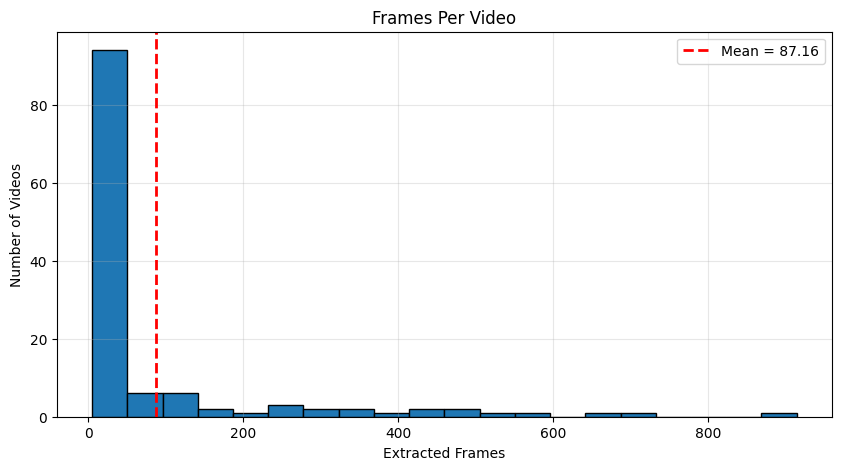

In [33]:
plt.figure(figsize=(10,5))

plt.hist(
    frame_stats_df["frames"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    frame_stats_df["frames"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {frame_stats_df['frames'].mean():.2f}"
)

plt.title("Frames Per Video")
plt.xlabel("Extracted Frames")
plt.ylabel("Number of Videos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12. Summary Statistics : 

In [34]:
frame_stats_df["frames"].describe()

count    126.000000
mean      87.158730
std      161.814482
min        5.000000
25%       13.000000
50%       19.500000
75%       52.250000
max      914.000000
Name: frames, dtype: float64

# 13. Check Minimum Frames : 

In [35]:
print("Minimum Frames : ", frame_stats_df["frames"].min())
print("Maximum Frames : ", frame_stats_df["frames"].max())
print("Average Frames : ", frame_stats_df["frames"].mean())

Minimum Frames :  5
Maximum Frames :  914
Average Frames :  87.15873015873017


# 14. Find Short Videos : 

In [36]:
short_videos = frame_stats_df[frame_stats_df["frames"] < 8]
print("Videos with <8 frames : ", len(short_videos))
short_videos.head()

Videos with <8 frames :  7


,patient,video,fps,duration_sec,total_frames,frames
25,patient25,colon-patient25-polyp1-M-64-ascending-neoplast...,25.04,5.95,149,6
64,patient99,colon-patient99-polyp1-M-47-descending-neoplas...,25.06,4.11,103,5
72,patient116,colon-patient116-polyp1-F-84-sigmoid-neoplasti...,29.59,4.26,126,5
80,patient127,colon-patient127-polyp1-F-77-rectum-nonneoplas...,25.00,5.96,149,6
84,patient134,colon-patient134-polyp1-M-66-descending-nonneo...,25.00,4.20,105,5


# 15. Save Valid Patients : 

In [37]:
MIN_FRAMES = 8
valid_patients = frame_stats_df[frame_stats_df["frames"] >= MIN_FRAMES]
valid_patients.to_csv("artifacts/valid_video_patients.csv", index=False)

print("Valid Patients : ", len(valid_patients))

Valid Patients :  119


# 16. Visual Inspection : 

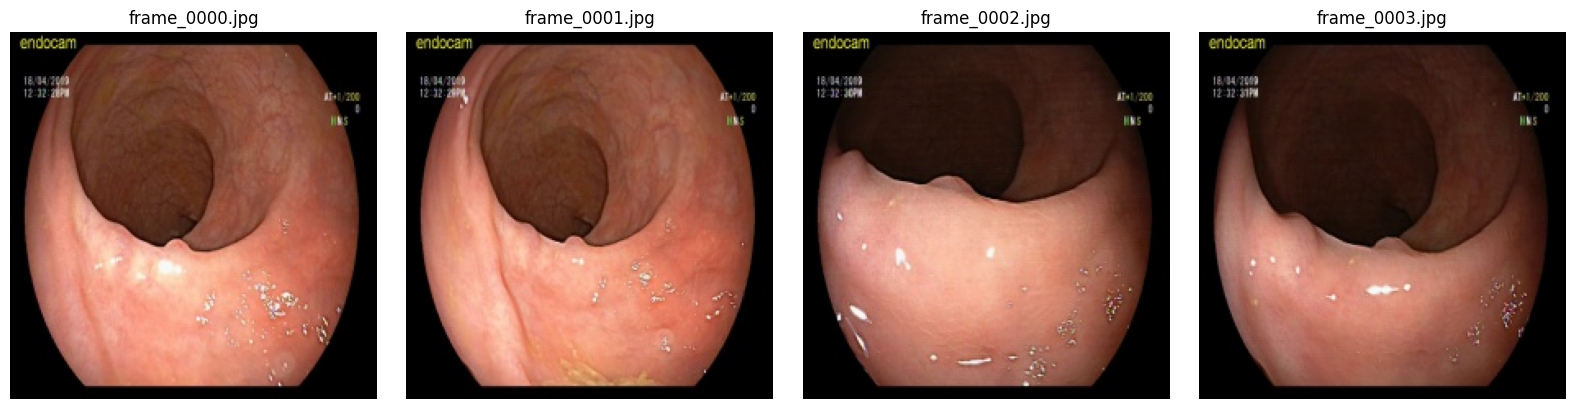

In [38]:
sample_patient = frame_stats_df.iloc[0]["patient"]

sample_folder = os.path.join(
    OUTPUT_FOLDER,
    sample_patient
)

images = sorted(os.listdir(sample_folder))

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,4)
)

for ax, image_name in zip(axes, images[:4]):

    img = cv2.imread(
        os.path.join(
            sample_folder,
            image_name
        )
    )
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    ax.imshow(img)
    ax.set_title(image_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 17. Notebook Summary : 

In [39]:
print("="*60)
print("NOTEBOOK 2 COMPLETED")
print("="*60)

print(f"Processed Videos      : {len(frame_stats_df)}")
print(f"Valid Patients        : {len(valid_patients)}")
print(f"Average Frames/Video  : {frame_stats_df['frames'].mean():.2f}")
print(f"Minimum Frames        : {frame_stats_df['frames'].min()}")
print(f"Maximum Frames        : {frame_stats_df['frames'].max()}")

print()

print("Frame Statistics Saved")
print("Missing Patient List Saved")
print("Ready for Notebook 3 (VideoMAE Feature Extraction)")

NOTEBOOK 2 COMPLETED
Processed Videos      : 126
Valid Patients        : 119
Average Frames/Video  : 87.16
Minimum Frames        : 5
Maximum Frames        : 914

Frame Statistics Saved
Missing Patient List Saved
Ready for Notebook 3 (VideoMAE Feature Extraction)


# Notebook 3 : VideoMAE-S Feature Extraction

# 1. Install Dependencies : 

In [61]:
!pip install transformers timm accelerate -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Import Libraries : 

In [40]:
import os
import torch
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import VideoMAEModel

# 3. Device Configeration : 

In [41]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


# 4. Load Valid Patients : 

In [42]:
valid_patients = pd.read_csv("artifacts/valid_video_patients.csv")
print(valid_patients.shape)
valid_patients.head()

(119, 6)


,patient,video,fps,duration_sec,total_frames,frames
0,patient58,colon-patient58-polyp1-M-42-rectum-nonneoplast...,25.02,18.99,475,19
1,patient85,colon-patient85-polyp1-M-83-sigmoid-nonneoplas...,25.02,13.71,343,14
2,patient92,colon-patient92-polyp1-M-61-rectum-nonneoplast...,25.02,19.07,477,20
3,patient109,colon-patient109-polyp1-M-45-sigmoid-nonneopla...,25.01,21.43,536,22
4,patient108,colon-patient108-polyp1-F-50-sigmoid-neoplasti...,25.97,36.66,952,37


# 5. Load Video MAE-S : 

In [43]:
model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
model.eval()
model.to(device)
print("VideoMAE Loaded")

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
encoder_to_decoder.weight                                            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.head.weight                                                  | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight        

VideoMAE Loaded


# 6. Define Frame Directory : 

In [44]:
FRAME_DIR = r"processed_data\video_frames"

# 7. Uniform Frame Sampling : 

In [45]:
def sample_frames(frame_paths, num_frames=16) :
    n = len(frame_paths)

    if n >= num_frames :
        idx = np.linspace(0, n-1, num_frames).astype(int)
        frame_paths = [frame_paths[i] for i in idx]

    else:

        while len(frame_paths) < num_frames:
            frame_paths.append(frame_paths[-1])

    return frame_paths

# 8. Frame Loader : 

In [46]:
def load_video_tensor(patient_folder, size=224) :
    frames = sorted([os.path.join(patient_folder, x)
        for x in os.listdir(
            patient_folder
        )
        if x.endswith(".jpg")
    ])
    frames = sample_frames(frames, num_frames=16)
    video = []

    for frame_path in frames :
        img = Image.open(frame_path).convert("RGB")
        img = img.resize((size,size))
        img = np.array(img)/255.0
        video.append(img)

    video = np.stack(video)
    video = torch.tensor(video, dtype=torch.float32)
    return video

# 9. Temporal Attention Pooling :  

In [47]:
video_features = []
patient_ids = []

# 10. Feature Extraction Loop : 

In [48]:
with torch.no_grad():

    for patient in tqdm(valid_patients["patient"]):
        patient_folder = os.path.join(
            FRAME_DIR,
            str(patient)
        )
        video = load_video_tensor(patient_folder)
        video = (
            video.permute(0, 3, 1, 2)
            .unsqueeze(0)
            .to(device)
        )

        outputs = model(pixel_values=video)
        # Raw VideoMAE token embeddings
        token_embeddings = outputs.last_hidden_state.squeeze(0)

        video_features.append(
            token_embeddings.cpu().numpy()
        )
        patient_ids.append(patient)

100%|████████████████████████████████████████████████████████████████████████████████| 119/119 [00:55<00:00,  2.16it/s]


# 11. Convert To NumPy : 

In [49]:
video_features = np.array(video_features)
print("Video Feature Shape :", video_features.shape)

Video Feature Shape : (119, 1568, 768)


# 12. Project To 512-D : 

In [50]:
print("Each patient contains token embeddings only.")
print("Projection layer will be trained in Notebook 8.")

Each patient contains token embeddings only.
Projection layer will be trained in Notebook 8.


# 13. Verify Shape : 

In [51]:
print(video_features.shape)

(119, 1568, 768)


# 14. Save Features : 

In [52]:
os.makedirs("features", exist_ok=True)
np.save(
    "features/video_features.npy",
    video_features
)
np.save(
    "features/video_patient_ids.npy",
    np.array(patient_ids)
)

print("Raw VideoMAE embeddings saved successfully.")

Raw VideoMAE embeddings saved successfully.


# 15. Feature Statistics : 

In [53]:
print("Mean :", video_features.mean())
print("Std  :", video_features.std())
print("Min  :", video_features.min())
print("Max  :", video_features.max())

Mean : 0.015739473
Std  : 0.6043828
Min  : -10.240185
Max  : 14.088872


# 16. Notebook Summary : 

In [54]:
print("=" * 60)
print("NOTEBOOK 3 COMPLETED")
print("=" * 60)

print("Patients        :", len(patient_ids))
print("Feature Shape   :", video_features.shape)
print("Embedding Size  : 768")
print("Status          : Raw VideoMAE embeddings saved")

NOTEBOOK 3 COMPLETED
Patients        : 119
Feature Shape   : (119, 1568, 768)
Embedding Size  : 768
Status          : Raw VideoMAE embeddings saved


# Notebook 4 : Histopathology Image Preparation & Patient-wise Organization

# 1. Import Libraries : 

In [55]:
import os
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt

# 2. Load Cleaned Pathology Dataset : 

In [56]:
pathology_df = pd.read_csv("artifacts/pathology_clean.csv")
print(pathology_df.shape)
pathology_df.head()

(1459, 18)


,ID,imageNames,patho,patient,polyp,location,type,subtype,zooming,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX10,15.0,strong,negative,weak,80.0,67.0,2.0,15.0,1
1,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX40,15.0,strong,negative,weak,80.0,67.0,2.0,15.0,1
2,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX5,15.0,strong,negative,weak,80.0,67.0,2.0,15.0,1
3,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX20,15.0,strong,negative,weak,80.0,67.0,2.0,15.0,1
4,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,"slideX2,5",15.0,strong,negative,weak,80.0,67.0,2.0,15.0,1


# 3. Basic Information : 

In [57]:
print("Unique Patients : ", pathology_df["patient"].nunique())
print("\nZoom Levels : ")
print(pathology_df["zooming"].value_counts())

Unique Patients :  194

Zoom Levels : 
zooming
slideX5        294
slideX2,5      293
slideX10       292
slideX20       290
slideX40       240
slideX20_1       8
slideX20_2       7
slideX10_2       6
slideX10_1       5
slideX5_2        4
slideX5_1        2
slideX5_3        2
slideX10_3       2
slideX2,5_2      2
slideX2,5_1      2
slideX5_4        2
slideX10_4       1
slideX40_1       1
slideX20_        1
slideX40_2       1
slideX5_5        1
slideX2,5_3      1
slideX2,5_4      1
slideX2,5_5      1
Name: count, dtype: int64


# 4. Define Pathology Root Folder : 

In [58]:
PATHO_ROOT = r"C:\Users\upadh\Downloads\histoImagesWithZoomingLabels"

# 5. Verify Image Counts In Each Folder : 

In [59]:
import os

for folder in os.listdir(PATHO_ROOT) :
    folder_path = os.path.join(PATHO_ROOT, folder)
    
    if os.path.isdir(folder_path) :
        print(folder, len(os.listdir(folder_path)))

10x 400
2,5x 393
20x 399
40x 316
5x 397


# 6. Inspect Image Name Format : 

In [60]:
pathology_df[["imageNames", "patient", "zooming"]].head(20)

,imageNames,patient,zooming
0,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX10
1,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX40
2,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX5
3,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX20
4,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,"slideX2,5"
5,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,"slideX2,5"
6,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,slideX5
7,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,slideX10
8,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,slideX40
9,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,slideX20


# 7. Inspect Actual Image Files from Each Magnification : 

In [61]:
import os

for folder in ["2,5x", "5x", "10x", "20x", "40x"] :
    folder_path = os.path.join(PATHO_ROOT, folder)
    files = os.listdir(folder_path)

    print("\n" + "="*50)
    print("Folder:", folder)
    print("Total Files:", len(files))
    print("Sample Files:")
    
    for f in files[:5] :
        print(f)


Folder: 2,5x
Total Files: 393
Sample Files:
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX2,5.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-slideX2,5.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX2,5_1.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX2,5_2.tiff
patho-patient100-normal-sigmoid-normal-inflammation-slideX2,5.tiff

Folder: 5x
Total Files: 397
Sample Files:
.DS_Store
patho-patient1-polyp1-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX5_1.tiff

Folder: 10x
Total Files: 400
Sample Files:
patho-patient1-polyp1-descending-nonneoplastic-hyperplastic-slideX10.tiff
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX10.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-

# 8. Check Patient Statistics : 

In [62]:
patient_counts = (pathology_df.groupby("patient").size())
patient_counts.describe()

count    194.000000
mean       7.520619
std        5.303444
min        3.000000
25%        5.000000
50%        5.000000
75%       10.000000
max       44.000000
dtype: float64

# 9. Image Per Patient : 

In [63]:
print("Minimum Images per Patient : ", patient_counts.min())
print("Maximum Images per Patient : ", patient_counts.max())
print("Average Images per Patient : ", round(patient_counts.mean(),2))

Minimum Images per Patient :  3
Maximum Images per Patient :  44
Average Images per Patient :  7.52


# 10. Check 20X Coverage : 

In [64]:
zoom20_df = pathology_df[
    pathology_df["zooming"]
    .str.contains("slideX20",
                  na=False)
]

print("20x Images : ", len(zoom20_df))
print("20x Patients : ", zoom20_df["patient"].nunique())

20x Images :  306
20x Patients :  194


# 11. Normalize Zoom Labels : 

In [65]:
def normalize_zoom(z) :
    z = str(z)

    if "slideX2,5" in z :
        return "2.5x"

    elif "slideX5" in z :
        return "5x"

    elif "slideX10" in z :
        return "10x"

    elif "slideX20" in z :
        return "20x"

    elif "slideX40" in z :
        return "40x"

    return "unknown"


pathology_df["zoom_level"] = (pathology_df["zooming"].apply(normalize_zoom))
pathology_df["zoom_level"].value_counts()

zoom_level
10x     306
20x     306
5x      305
2.5x    300
40x     242
Name: count, dtype: int64

# 12. Tissue Patch Selection (Best Magnification) : 

In [66]:
BEST_ZOOM = "20x"

best_zoom_df = pathology_df[
    pathology_df["zoom_level"]
    == BEST_ZOOM
].copy()

print(best_zoom_df.shape)

(306, 19)


In [67]:
print("20x Patients : ", zoom20_df["patient"].nunique())

20x Patients :  194


# 13. Normalize Zoom Levels : 

In [68]:
def normalize_zoom(z) :
    z = str(z)

    if "slideX2,5" in z :
        return "2.5x"

    elif "slideX5" in z :
        return "5x"

    elif "slideX10" in z :
        return "10x"

    elif "slideX20" in z :
        return "20x"

    elif "slideX40" in z :
        return "40x"

    return "unknown"


pathology_df["zoom_level"] = pathology_df["zooming"].apply(normalize_zoom)
pathology_df["zoom_level"].value_counts()

zoom_level
10x     306
20x     306
5x      305
2.5x    300
40x     242
Name: count, dtype: int64

# 14. Verify Normalized Distribution : 

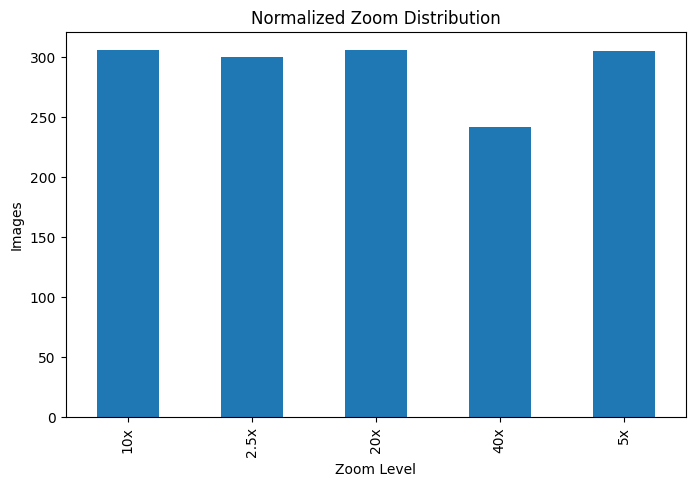

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
pathology_df["zoom_level"]\
    .value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.title("Normalized Zoom Distribution")
plt.xlabel("Zoom Level")
plt.ylabel("Images")
plt.show()

# 15. Check Patirnt Coverage Per Zoom : 

In [70]:
zoom_patient_stats = (pathology_df.groupby("zoom_level")["patient"].nunique())
print(zoom_patient_stats)

zoom_level
10x     194
2.5x    193
20x     194
40x     159
5x      193
Name: patient, dtype: int64


# 16. Create Multi-Scale Patient Mapping : 

In [71]:
patient_multiscale_map = {}

for patient, group in pathology_df.groupby("patient") :
    patient_multiscale_map[patient] = {
        "2.5x": [],
        "5x": [],
        "10x": [],
        "20x": [],
        "40x": []
    }

    for _, row in group.iterrows() :
        zoom = row["zoom_level"]
        if zoom in patient_multiscale_map[patient] :
            patient_multiscale_map[
                patient
            ][zoom].append(
                row["imageNames"]
            )

print("Patients : ", len(patient_multiscale_map))

Patients :  194


# 17. Inspect One Patient : 

In [72]:
sample_patient = list(patient_multiscale_map.keys())[0]
print("Patient : ", sample_patient)
for zoom, imgs in (patient_multiscale_map[sample_patient].items()) :
    print(zoom, len(imgs))

Patient :  patient1
2.5x 2
5x 3
10x 3
20x 3
40x 1


# 18. Total Images Per Scale : 

In [73]:
scale_counts = {}

for zoom in ["2.5x", "5x", "10x", "20x", "40x"]:
    scale_counts[zoom] = len(
        pathology_df[
            pathology_df["zoom_level"] == zoom
        ]
    )

pd.Series(scale_counts)

2.5x    300
5x      305
10x     306
20x     306
40x     242
dtype: int64

# 19. Patient Level Statistics : 

In [74]:
patient_image_counts = []
for patient in patient_multiscale_map :
    total_images = 0
    for zoom in patient_multiscale_map[patient] :
        total_images += len(
            patient_multiscale_map[
                patient
            ][zoom]
        )

    patient_image_counts.append(total_images)

pd.Series(patient_image_counts).describe()

count    194.000000
mean       7.520619
std        5.303444
min        3.000000
25%        5.000000
50%        5.000000
75%       10.000000
max       44.000000
dtype: float64

# 20. Save Multi Scale Mapping : 

In [75]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    patient_multiscale_map,
    "artifacts/patient_multiscale_map.pkl"
)

print("Saved Successfully")

Saved Successfully


# 21. Save Processed Dataframe : 

In [76]:
# =====================================================
# Save Updated Pathology Metadata
# =====================================================

import os
import joblib

os.makedirs("artifacts", exist_ok=True)

# Save complete multiscale pathology dataframe
pathology_df.to_csv(
    "artifacts/pathology_multiscale.csv",
    index=False
)

# Save patient → multiscale image mapping
joblib.dump(
    patient_multiscale_map,
    "artifacts/patient_multiscale_map.pkl"
)

print("=" * 60)
print("PATHOLOGY DATA SAVED")
print("=" * 60)

print("Patients :", pathology_df["patient"].nunique())
print("Images   :", len(pathology_df))
print("Zoom Levels :", sorted(pathology_df["zoom_level"].unique()))

print("\nFiles Saved:")
print("✓ artifacts/pathology_multiscale.csv")
print("✓ artifacts/patient_multiscale_map.pkl")

PATHOLOGY DATA SAVED
Patients : 194
Images   : 1459
Zoom Levels : ['10x', '2.5x', '20x', '40x', '5x']

Files Saved:
✓ artifacts/pathology_multiscale.csv
✓ artifacts/patient_multiscale_map.pkl


# 22. Notebook Summary : 

In [77]:
print("="*60)
print("NOTEBOOK 4 COMPLETE")
print("="*60)

print("Patients : ", len(patient_multiscale_map))
print("Total Images : ", len(pathology_df))
print("Average Images Per Patient : ", round(np.mean(patient_image_counts), 2))

NOTEBOOK 4 COMPLETE
Patients :  194
Total Images :  1459
Average Images Per Patient :  7.52


# Notebook 5 : Multi-Scale DINOv2 Pathology Feature Extraction

# 1. Install Dependencies : 

In [101]:
!pip install transformers timm accelerate -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Import Libraries : 

In [78]:
import os
import joblib
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from PIL import Image

from transformers import AutoImageProcessor
from transformers import AutoModel

# 3. Device : 

In [79]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


# 4. Load Mapping : 

In [80]:
patient_multiscale_map = joblib.load("artifacts/patient_multiscale_map.pkl")
print("Patients : ", len(patient_multiscale_map))

Patients :  194


# 5. Pathology Root : 

In [81]:
PATHO_ROOT = r"C:\Users\upadh\Downloads\histoImagesWithZoomingLabels"
ZOOM_FOLDERS = {
    "2.5x" : "2,5x",
    "5x" : "5x",
    "10x" : "10x",
    "20x" : "20x",
    "40x" : "40x"
}

# 6. Load DINOv2 : 

In [82]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dinov2 = AutoModel.from_pretrained(
    "facebook/dinov2-base"
)

# Freeze DINOv2
for param in dinov2.parameters() :
    param.requires_grad = False

dinov2.eval()
dinov2.to(device)

print("Frozen DINOv2 Loaded")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Frozen DINOv2 Loaded


# 7. Image Loader : 

In [83]:
def load_image(img_path) :
    img = Image.open(img_path).convert("RGB")

    return img

# 8. DINOv2 Feature Extractor : 

In [84]:
@torch.no_grad()
def extract_patch_features(img):
    inputs = processor(
        images=img,
        return_tensors="pt"
    )
    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }
    outputs = dinov2(**inputs)

    # remove CLS token

    patch_tokens = outputs.last_hidden_state[:,1:,:]
    return patch_tokens.squeeze(0).cpu()

# 9. Initialize Storage :  

In [85]:
# =====================================================
# Storage for Raw Patch Embeddings
# =====================================================

pathology_features = []
patient_ids = []

# 10. Extract Raw Patch Embeddings for Every Patient : 

In [86]:
# =====================================================
# Extract Raw Patch Embeddings
# =====================================================

for patient in tqdm(patient_multiscale_map.keys()):

    patient_embeddings = []

    for zoom in patient_multiscale_map[patient]:

        img_names = patient_multiscale_map[patient][zoom]

        for img_name in img_names:

            folder = ZOOM_FOLDERS[zoom]
            img_path = os.path.join(PATHO_ROOT, folder, img_name)

            if not os.path.exists(img_path):
                continue

            try:

                img = load_image(img_path)

                # (256,768)
                patch_tokens = extract_patch_features(img)

                # Store as float32 to reduce file size
                patient_embeddings.append(
                    patch_tokens.cpu().numpy().astype(np.float32)
                )

            except Exception as e:

                print(f"Error : {patient} | {img_name}")
                print(e)

    if len(patient_embeddings) == 0:
        continue

    pathology_features.append(patient_embeddings)
    patient_ids.append(patient)

100%|████████████████████████████████████████████████████████████████████████████████| 194/194 [06:03<00:00,  1.87s/it]


# 11. Check Data : 

In [87]:
print("=" * 60)
print("RAW PATHOLOGY EMBEDDINGS")
print("=" * 60)

print("Patients :", len(pathology_features))
print("Example Patient :", patient_ids[0])
print("Images for Example Patient :", len(pathology_features[0]))
print("Patch Tokens/Image :", pathology_features[0][0].shape[0])
print("Embedding Dimension :", pathology_features[0][0].shape[1])

RAW PATHOLOGY EMBEDDINGS
Patients : 194
Example Patient : patient1
Images for Example Patient : 12
Patch Tokens/Image : 256
Embedding Dimension : 768


# 12. Save Features : 

In [88]:
import os

os.makedirs("features", exist_ok=True)

np.save(
    "features/pathology_patch_embeddings.npy",
    np.array(pathology_features, dtype=object),
    allow_pickle=True
)

np.save(
    "features/pathology_patient_ids.npy",
    np.array(patient_ids)
)

print("Raw pathology patch embeddings saved successfully.")

Raw pathology patch embeddings saved successfully.


# 13. Verify Saved Data : 

In [89]:
loaded_features = np.load(
    "features/pathology_patch_embeddings.npy",
    allow_pickle=True
)

loaded_ids = np.load(
    "features/pathology_patient_ids.npy"
)

print("Patients :", len(loaded_features))
print("Patient IDs :", len(loaded_ids))
print("Example Image Shape :", loaded_features[0][0].shape)

Patients : 194
Patient IDs : 194
Example Image Shape : (256, 768)


# 14. Feature Statistics :

In [90]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Patients               : {len(loaded_features)}")
print(f"Embedding Dimension    : {loaded_features[0][0].shape[1]}")
print(f"Patch Tokens per Image : {loaded_features[0][0].shape[0]}")

image_counts = [len(patient) for patient in loaded_features]

print(f"Average Images/Patient : {np.mean(image_counts):.2f}")
print(f"Minimum Images/Patient : {np.min(image_counts)}")
print(f"Maximum Images/Patient : {np.max(image_counts)}")

DATASET SUMMARY
Patients               : 194
Embedding Dimension    : 768
Patch Tokens per Image : 256
Average Images/Patient : 7.52
Minimum Images/Patient : 3
Maximum Images/Patient : 44


# 15. Notebook Summary : 

In [91]:
print("=" * 60)
print("NOTEBOOK 5 COMPLETED")
print("=" * 60)

print(f"Patients Processed : {len(patient_ids)}")

print("\nSaved Files")
print("---------------------------")
print("✓ pathology_patch_embeddings.npy")
print("✓ pathology_patient_ids.npy")

print("\nRemoved from Notebook 5")
print("---------------------------")
print("✓ Patch Attention")
print("✓ Patient Attention")
print("✓ Projection Layer")

print("\nThese modules will now be trained end-to-end in Notebook 8.")

NOTEBOOK 5 COMPLETED
Patients Processed : 194

Saved Files
---------------------------
✓ pathology_patch_embeddings.npy
✓ pathology_patient_ids.npy

Removed from Notebook 5
---------------------------
✓ Patch Attention
✓ Patient Attention
✓ Projection Layer

These modules will now be trained end-to-end in Notebook 8.


# Notebook 6 : IHC Biomarker Embedding

# 1. Import Libraries ; 

In [92]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

# 2. Load Dataset : 

In [93]:
ihc_df = pd.read_csv("artifacts/ihc_clean.csv")

print(ihc_df.shape)
ihc_df.head()

(309, 18)


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,1,colon,patient1,polyp1,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,20.0,47.0,2.0,15.0,1
1,1,colon,patient1,polyp2,M,53,descending,nonneoplastic,hyperplastic,40.0,negative,negative,negative,30.0,39.0,2.0,10.0,1
2,1,colon,patient1,polyp3,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,50.0,50.0,3.0,20.0,1
3,2,colon,patient2,polyp1,M,49,ascending,nonneoplastic,hyperplastic,50.0,negative,negative,weak,40.0,63.0,3.0,5.0,1
4,2,colon,patient2,polyp2,M,49,descending,neoplastic,villous,60.0,negative,negative,weak,70.0,57.0,2.0,25.0,0


# 3. Check Unique Patients : 

In [94]:
print("Unique Patients : ", ihc_df["patient"].nunique())
print("Unique Polyps : ", ihc_df["polyp"].nunique())

Unique Patients :  196
Unique Polyps :  13


In [95]:
feature_cols = [
    "gender",
    "age",
    "location",
    "Ki-67(clone30-9)",
    "BRAF(cloneV600E)",
    "PD-L1epithelium(clone SP142)",
    "PD-L1lymphocyte(clone SP142)",
    "VEGF(clone SP125)",
    "CD34(cloneQBend/10)",
    "CD34(cloneQBend/10)skor",
    "p53(clonebp53-11)"
]

# 4. Seperate Numeric and Categorical Columns : 

In [96]:
numeric_cols = [
    "age",
    "Ki-67(clone30-9)",
    "VEGF(clone SP125)",
    "CD34(cloneQBend/10)",
    "CD34(cloneQBend/10)skor",
    "p53(clonebp53-11)"
]

categorical_cols = [
    "gender",
    "location",
    "BRAF(cloneV600E)",
    "PD-L1epithelium(clone SP142)",
    "PD-L1lymphocyte(clone SP142)"
]

# 5. Aggregate Per Patient : 

In [97]:
numeric_df = (ihc_df.groupby("patient")[numeric_cols].mean())

# 6. Aggregate Categoricals : 

In [98]:
categorical_df = (
    ihc_df
    .groupby("patient")[categorical_cols]
    .agg(
        lambda x : x.mode().iloc[0]
        if len(x.mode()) > 0
        else x.iloc[0]
    )
)

# 7. Merge Patient Records : 

In [99]:
patient_df = pd.concat(
    [numeric_df, categorical_df],
    axis=1
).reset_index()

# 8. Verify : 

In [100]:
print(patient_df.shape)
patient_df.head()

(196, 12)


,patient,age,Ki-67(clone30-9),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),gender,location,BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142)
0,patient1,53.0,46.666667,33.333333,45.333333,2.333333,15.0,M,descending,negative,negative,negative
1,patient10,83.0,70.000000,50.000000,58.000000,2.000000,50.0,M,rectum,negative,negative,weak
2,patient100,72.0,25.000000,83.333333,56.333333,2.000000,20.0,F,sigmoid,negative,negative,weak
3,patient101,63.0,25.000000,20.000000,30.000000,1.000000,10.0,F,sigmoid,negative,negative,weak
4,patient102,65.0,20.000000,0.000000,27.000000,1.000000,15.0,M,descending,negative,negative,weak


# 9. Missing Values : 

In [101]:
patient_df.isnull().sum()

patient                         0
age                             0
Ki-67(clone30-9)                6
VEGF(clone SP125)               5
CD34(cloneQBend/10)             5
CD34(cloneQBend/10)skor         5
p53(clonebp53-11)               5
gender                          0
location                        0
BRAF(cloneV600E)                5
PD-L1epithelium(clone SP142)    5
PD-L1lymphocyte(clone SP142)    5
dtype: int64

# 10. Fill Missing Values : 

In [102]:
for col in patient_df.columns :
    if col == "patient" :
        continue

    if patient_df[col].dtype == "object" :
        patient_df[col] = (
            patient_df[col]
            .fillna(
                patient_df[col].mode()[0]
            )
        )

    else :
        patient_df[col] = (
            patient_df[col]
            .fillna(
                patient_df[col].median()
            )
        )

# 11. Prepare Feature Matrix : 

In [103]:
X = patient_df.drop(columns=["patient"])
print(X.shape)

(196, 11)


# 12. Encode Categoricals : 

In [104]:
from sklearn.preprocessing import LabelEncoder
import joblib
import os

encoders = {}

for col in X.columns:

    if X[col].dtype == "object":

        le = LabelEncoder()

        X[col] = le.fit_transform(
            X[col].astype(str)
        )

        encoders[col] = le

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    encoders,
    "artifacts/ihc_label_encoders.pkl"
)

print("Categorical features encoded.")
print("Label encoders saved.")

Categorical features encoded.
Label encoders saved.


# 13. Standardize : 

In [105]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    "artifacts/ihc_scaler.pkl"
)

print("Scaled Feature Shape :", X_scaled.shape)
print("Scaler saved.")

Scaled Feature Shape : (196, 11)
Scaler saved.


# 14. Save Aggregated Patient Table : 

In [106]:
patient_df.to_csv(
    "artifacts/ihc_patient_level.csv",
    index=False
)

print("Patient-level metadata saved.")

Patient-level metadata saved.


In [107]:
patient_df.shape

(196, 12)

In [108]:
patient_df.head()

,patient,age,Ki-67(clone30-9),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),gender,location,BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142)
0,patient1,53.0,46.666667,33.333333,45.333333,2.333333,15.0,M,descending,negative,negative,negative
1,patient10,83.0,70.000000,50.000000,58.000000,2.000000,50.0,M,rectum,negative,negative,weak
2,patient100,72.0,25.000000,83.333333,56.333333,2.000000,20.0,F,sigmoid,negative,negative,weak
3,patient101,63.0,25.000000,20.000000,30.000000,1.000000,10.0,F,sigmoid,negative,negative,weak
4,patient102,65.0,20.000000,0.000000,27.000000,1.000000,15.0,M,descending,negative,negative,weak


# 15. Convert To Tensor : 

In [109]:
X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

print("Tensor Shape :", X_tensor.shape)

Tensor Shape : torch.Size([196, 11])


# 16. Prepare Final IHC Features : 

In [110]:
# ==========================================================
# Final IHC Features
# ==========================================================

# Save standardized 11-dimensional features.
# TabTransformer will be trained later in Notebook 8.

patient_ids = patient_df["patient"].astype(str).values

print("=" * 60)
print("FINAL IHC FEATURES")
print("=" * 60)

print("Patients :", len(patient_ids))
print("Feature Shape :", X_scaled.shape)
print("Feature Dimension :", X_scaled.shape[1])

FINAL IHC FEATURES
Patients : 196
Feature Shape : (196, 11)
Feature Dimension : 11


# 17. Save Features : 

In [111]:
os.makedirs("features", exist_ok=True)

np.save(
    "features/ihc_raw_features.npy",
    X_scaled.astype(np.float32)
)

np.save(
    "features/ihc_patient_ids.npy",
    patient_ids
)

print("Raw IHC features saved successfully.")

Raw IHC features saved successfully.


# 18. Check Shape: 

In [112]:
loaded = np.load(
    "features/ihc_raw_features.npy"
)

print("Loaded Shape :", loaded.shape)
print("Data Type :", loaded.dtype)

Loaded Shape : (196, 11)
Data Type : float32


# 19. Verify Saved Features : 

In [113]:
loaded_features = np.load(
    "features/ihc_raw_features.npy"
)

loaded_ids = np.load(
    "features/ihc_patient_ids.npy",
    allow_pickle=True
)

print("Feature Shape :", loaded_features.shape)
print("Patient IDs Shape :", loaded_ids.shape)
print("First 5 Patient IDs :", loaded_ids[:5])

Feature Shape : (196, 11)
Patient IDs Shape : (196,)
First 5 Patient IDs : ['patient1' 'patient10' 'patient100' 'patient101' 'patient102']


# 20. Feature Statistics : 

In [114]:
print("Mean :", np.mean(loaded_features))
print("Std  :", np.std(loaded_features))
print("Min  :", np.min(loaded_features))
print("Max  :", np.max(loaded_features))

Mean : 5.7503553e-09
Std  : 1.0
Min  : -3.7878633
Max  : 5.3017106


# 21. Summary : 

In [115]:
print("=" * 60)
print("NOTEBOOK 6 COMPLETED")
print("=" * 60)

print("Patients :", len(patient_ids))
print("Feature Shape :", loaded_features.shape)

print("\nSaved Files")
print("---------------------------")
print("✓ features/ihc_raw_features.npy")
print("✓ features/ihc_patient_ids.npy")
print("✓ artifacts/ihc_patient_level.csv")
print("✓ artifacts/ihc_label_encoders.pkl")
print("✓ artifacts/ihc_scaler.pkl")

print("\nNotebook 8 will train:")
print("---------------------------")
print("✓ Biomarker Projection Layer")
print("✓ Biomarker Gate")
print("✓ Multimodal Fusion Network")

NOTEBOOK 6 COMPLETED
Patients : 196
Feature Shape : (196, 11)

Saved Files
---------------------------
✓ features/ihc_raw_features.npy
✓ features/ihc_patient_ids.npy
✓ artifacts/ihc_patient_level.csv
✓ artifacts/ihc_label_encoders.pkl
✓ artifacts/ihc_scaler.pkl

Notebook 8 will train:
---------------------------
✓ Biomarker Projection Layer
✓ Biomarker Gate
✓ Multimodal Fusion Network


# Notebook 7 : Patient Alignment & Multimodal Dataset Creation

# 1. Import Libraries : 

In [116]:
import numpy as np
import pandas as pd

# 2. Load Patient IDs : 

In [117]:
video_patients = np.load(
    "features/video_patient_ids.npy",
    allow_pickle=True
)

pathology_patients = np.load(
    "features/pathology_patient_ids.npy",
    allow_pickle=True
)

ihc_patients = np.load(
    "features/ihc_patient_ids.npy",
    allow_pickle=True
)

print("Video Patients      :", len(video_patients))
print("Pathology Patients  :", len(pathology_patients))
print("IHC Patients        :", len(ihc_patients))

Video Patients      : 119
Pathology Patients  : 194
IHC Patients        : 196


# 3. Load Features : 

In [118]:
video_features = np.load(
    "features/video_features.npy",
    allow_pickle=True
)

pathology_features = np.load(
    "features/pathology_patch_embeddings.npy",
    allow_pickle=True
)

ihc_features = np.load(
    "features/ihc_raw_features.npy",
    allow_pickle=True
)

print("Video Shape      :", video_features.shape)
print("Pathology Shape  :", pathology_features.shape)
print("IHC Shape        :", ihc_features.shape)

Video Shape      : (119, 1568, 768)
Pathology Shape  : (194,)
IHC Shape        : (196, 11)


# 4. Find Common Patients : 

In [119]:
video_set = set(video_patients)
pathology_set = set(pathology_patients)
ihc_set = set(ihc_patients)

common_patients = sorted(
    list(video_set & pathology_set & ihc_set)
)

print("Video Patients      :", len(video_set))
print("Pathology Patients  :", len(pathology_set))
print("IHC Patients        :", len(ihc_set))
print("Common Patients     :", len(common_patients))

Video Patients      : 118
Pathology Patients  : 194
IHC Patients        : 196
Common Patients     : 117


# 5. Create Patient To Index Mapping ; 

In [120]:
video_index = {
    patient: idx
    for idx, patient in enumerate(video_patients)
}

pathology_index = {
    patient: idx
    for idx, patient in enumerate(pathology_patients)
}

ihc_index = {
    patient: idx
    for idx, patient in enumerate(ihc_patients)
}

print("Index Mapping Created")

Index Mapping Created


# 6. Allign Features  : 

In [121]:
aligned_video = []
aligned_pathology = []
aligned_ihc = []

for patient in common_patients:

    aligned_video.append(
        video_features[
            video_index[patient]
        ]
    )

    aligned_pathology.append(
        pathology_features[
            pathology_index[patient]
        ]
    )

    aligned_ihc.append(
        ihc_features[
            ihc_index[patient]
        ]
    )

print("Alignment Completed")
print("Aligned Patients :", len(aligned_video))

Alignment Completed
Aligned Patients : 117


# 7. Convert To NumPy Arrays : 

In [122]:
# ----------------------------------------
# Convert Video to numeric array
# ----------------------------------------

aligned_video = np.stack(
    aligned_video
).astype(np.float32)

# ----------------------------------------
# Keep pathology as object array
# ----------------------------------------

aligned_pathology = np.array(
    aligned_pathology,
    dtype=object
)

# ----------------------------------------
# IHC
# ----------------------------------------

aligned_ihc = np.stack(
    aligned_ihc
).astype(np.float32)

print("Video Shape      :", aligned_video.shape)
print("Pathology Shape  :", aligned_pathology.shape)
print("IHC Shape        :", aligned_ihc.shape)

Video Shape      : (117, 1568, 768)
Pathology Shape  : (117,)
IHC Shape        : (117, 11)


# 8. Create Labels : 

In [123]:
video_df = pd.read_csv(
    "artifacts/video_clean.csv"
)

patient_label_map = (
    video_df
    .drop_duplicates("patient")
    .set_index("patient")["LabelID"]
    .to_dict()
)

labels = np.array(
    [
        patient_label_map[p]
        for p in common_patients
    ],
    dtype=np.int64
)

print("Labels Shape :", labels.shape)
print(pd.Series(labels).value_counts())

Labels Shape : (117,)
0    72
1    45
Name: count, dtype: int64


# 9. Save Alligned Features : 

In [124]:
import os

os.makedirs("features", exist_ok=True)

# -------------------------------
# Video Features
# -------------------------------
np.save(
    "features/aligned_video.npy",
    aligned_video
)

# -------------------------------
# Pathology Features
# -------------------------------
np.save(
    "features/aligned_pathology.npy",
    aligned_pathology,
    allow_pickle=True
)

# -------------------------------
# IHC Features
# -------------------------------
np.save(
    "features/aligned_ihc.npy",
    aligned_ihc
)

# -------------------------------
# Labels
# -------------------------------
np.save(
    "features/aligned_labels.npy",
    labels
)

# -------------------------------
# Common Patients
# -------------------------------
np.save(
    "features/common_patients.npy",
    np.array(common_patients)
)

print("All aligned features saved successfully.")

All aligned features saved successfully.


# 10. Verify Saved Files : 

In [125]:
video = np.load(
    "features/aligned_video.npy"
)

pathology = np.load(
    "features/aligned_pathology.npy",
    allow_pickle=True
)

ihc = np.load(
    "features/aligned_ihc.npy"
)

labels = np.load(
    "features/aligned_labels.npy"
)

patients = np.load(
    "features/common_patients.npy",
    allow_pickle=True
)

print("Video Shape      :", video.shape)
print("Pathology Shape  :", pathology.shape)
print("IHC Shape        :", ihc.shape)
print("Labels Shape     :", labels.shape)
print("Patients         :", len(patients))

Video Shape      : (117, 1568, 768)
Pathology Shape  : (117,)
IHC Shape        : (117, 11)
Labels Shape     : (117,)
Patients         : 117


# 11. Dataset Statistics : 

In [126]:
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Total Patients : {len(common_patients)}")
print(f"Video Shape    : {aligned_video.shape}")
print(f"Pathology Patients : {len(aligned_pathology)}")
print(f"IHC Shape      : {aligned_ihc.shape}")
print(f"Classes        : {np.unique(labels)}")

print("\nClass Distribution")
print(pd.Series(labels).value_counts().sort_index())

DATASET STATISTICS
Total Patients : 117
Video Shape    : (117, 1568, 768)
Pathology Patients : 117
IHC Shape      : (117, 11)
Classes        : [0 1]

Class Distribution
0    72
1    45
Name: count, dtype: int64


# 12. Notebook Completion : 

In [127]:
print("=" * 60)
print("NOTEBOOK 7 COMPLETED")
print("=" * 60)

print("✓ Video features aligned")
print("✓ Pathology patch embeddings aligned")
print("✓ IHC features aligned")
print("✓ Labels generated")
print("✓ All files saved")

print("\nSaved Files")
print("features/aligned_video.npy")
print("features/aligned_pathology.npy")
print("features/aligned_ihc.npy")
print("features/aligned_labels.npy")
print("features/common_patients.npy")

NOTEBOOK 7 COMPLETED
✓ Video features aligned
✓ Pathology patch embeddings aligned
✓ IHC features aligned
✓ Labels generated
✓ All files saved

Saved Files
features/aligned_video.npy
features/aligned_pathology.npy
features/aligned_ihc.npy
features/aligned_labels.npy
features/common_patients.npy


# Notebook 8 : Multimodal Fusion Model Training

# 1. Import Libraries : 

In [187]:
import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.utils.class_weight import compute_class_weight

# 2. Reproducibility : 

In [188]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 60)
print("Device :", DEVICE)
print("=" * 60)

Device : cuda


# 3. Load Alligned Features : 

In [189]:
# ==========================================================
# Load Aligned Features
# ==========================================================

video_features = np.load(
    "features/aligned_video.npy"
).astype(np.float32)

pathology_features = np.load(
    "features/aligned_pathology.npy",
    allow_pickle=True
)

ihc_features = np.load(
    "features/aligned_ihc.npy"
).astype(np.float32)

labels = np.load(
    "features/aligned_labels.npy"
).astype(np.int64)

print("=" * 60)
print("DATA LOADED")
print("=" * 60)

print("Video Shape      :", video_features.shape)
print("Pathology Length :", len(pathology_features))
print("IHC Shape        :", ihc_features.shape)
print("Labels Shape     :", labels.shape)

print()

print("Example Video :", video_features[0].shape)
print("Patient Images :", len(pathology_features[0]))
print("Example Patch Shape :", pathology_features[0][0].shape)
print("Example IHC :", ihc_features[0].shape)

DATA LOADED
Video Shape      : (117, 1568, 768)
Pathology Length : 117
IHC Shape        : (117, 11)
Labels Shape     : (117,)

Example Video : (1568, 768)
Patient Images : 12
Example Patch Shape : (256, 768)
Example IHC : (11,)


# 4. Multimodal Dataset : 

In [190]:
# ==========================================================
# Multimodal Dataset
# ==========================================================

class MultimodalDataset(Dataset) :
    def __init__(self, video, pathology, ihc, labels) :
        self.video = video
        self.pathology = pathology
        self.ihc = ihc
        self.labels = labels

    def __len__(self) :
        return len(self.labels)

    def __getitem__(self, idx) :
        return (self.video[idx], self.pathology[idx], self.ihc[idx], self.labels[idx])

# 5. Custom Collate Function : 

In [191]:
# ==========================================================
# Custom Collate Function
# ==========================================================

def multimodal_collate_fn(batch) :
    video_batch = []
    pathology_batch = []
    ihc_batch = []
    label_batch = []

    for video, pathology, ihc, label in batch :
        # -------------------------
        # Video
        # (1568,768)
        # -------------------------
        video_batch.append(
            torch.tensor(
                video,
                dtype=torch.float32
            )
        )

        # -------------------------
        # Pathology
        # list of (256,768)
        # Keep as list
        # -------------------------

        patient_images = []

        for img in pathology :

            patient_images.append(
                torch.tensor(
                    img,
                    dtype=torch.float32
                )
            )

        pathology_batch.append(patient_images)

        # -------------------------
        # IHC
        # (11,)
        # -------------------------

        ihc_batch.append(
            torch.tensor(
                ihc,
                dtype=torch.float32
            )
        )

        # -------------------------
        # Label
        # -------------------------

        label_batch.append(label)

    video_batch = torch.stack(video_batch)
    ihc_batch = torch.stack(ihc_batch)
    label_batch = torch.tensor(
        label_batch,
        dtype=torch.long
    )

    return (video_batch, pathology_batch, ihc_batch, label_batch)


print("Custom Dataset Ready")
print("Custom Collate Function Ready")

Custom Dataset Ready
Custom Collate Function Ready


# 6. Class Weights + Focal Loss : 

In [192]:
# ==========================================================
# Class Weights
# ==========================================================

classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)

# Smooth extreme imbalance
class_weights = np.sqrt(class_weights)
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("="*60)
print("CLASS WEIGHTS")
print("="*60)
print(class_weights)


# ==========================================================
# Focal Loss
# ==========================================================

class FocalLoss(nn.Module) :
    def __init__(self, alpha=None, gamma=1.5) :
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets) :
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


criterion = FocalLoss(alpha=class_weights, gamma=2.0)

print("Focal Loss Ready")

CLASS WEIGHTS
tensor([0.9014, 1.1402], device='cuda:0')
Focal Loss Ready


# 7. Attention Modules : 

In [193]:
# ==========================================================
# Temporal Attention
# Input : (1568,768)
# Output: (768)
# ==========================================================

class TemporalAttention(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(768,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x):
        score = self.attention(x)
        weight = torch.softmax(
            score,
            dim=0
        )
        out = torch.sum(
            weight*x,
            dim=0
        )
        return out


# ==========================================================
# Patch Attention
# Input : (256,768)
# Output: (768)
# ==========================================================

class PatchAttention(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(768,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x) :
        score = self.attention(x)
        weight = torch.softmax(
            score,
            dim=0
        )
        out = torch.sum(
            weight*x,
            dim=0
        )
        return out


# ==========================================================
# Patient Attention
# Input : (num_images,768)
# Output: (768)
# ==========================================================

class PatientAttention(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(768,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x) :
        score = self.attention(x)
        weight = torch.softmax(
            score,
            dim=0
        )
        out = torch.sum(
            weight*x,
            dim=0
        )
        return out


print("Temporal Attention Ready")
print("Patch Attention Ready")
print("Patient Attention Ready")

Temporal Attention Ready
Patch Attention Ready
Patient Attention Ready


# 8. Complete Multimodal Fusion Network : 

In [194]:
# ==========================================================
# Cell 8 : Complete Multimodal Fusion Network
# ==========================================================

class TemporalAttention(nn.Module) :
    def __init__(self, feature_dim=768) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x) :
        score = self.attention(x)
        weight = torch.softmax(score,dim=0)
        return torch.sum(weight*x,dim=0)


# ==========================================================

class PatchAttention(nn.Module) :
    def __init__(self, feature_dim=768) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x) :
        score = self.attention(x)
        weight = torch.softmax(score,dim=0)
        return torch.sum(weight*x,dim=0)


# ==========================================================

class PatientAttention(nn.Module) :
    def __init__(self,feature_dim=768) :
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim,256),
            nn.Tanh(),
            nn.Linear(256,1)
        )

    def forward(self,x) :
        score = self.attention(x)
        weight = torch.softmax(score,dim=0)
        return torch.sum(weight*x,dim=0)


# ==========================================================
# Multimodal Network
# ==========================================================

class MultimodalFusionNet(nn.Module) :
    def __init__(self) :
        super().__init__()

        ###############################################
        # Attention
        ###############################################

        self.temporal_attention = TemporalAttention()
        self.patch_attention = PatchAttention()
        self.patient_attention = PatientAttention()

        ###############################################
        # Video Projection
        ###############################################

        self.video_projection = nn.Sequential(
            nn.Linear(768,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.30)

        )

        ###############################################
        # Pathology Projection
        ###############################################

        self.pathology_projection = nn.Sequential(
            nn.Linear(768,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.30)

        )

        ###############################################
        # IHC Branch
        ###############################################

        self.ihc_branch = nn.Sequential(
            nn.Linear(11,128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.20)

        )

        ###############################################
        # Biomarker Gate
        ###############################################

        self.gate = nn.Sequential(
            nn.Linear(128,512),
            nn.Sigmoid()

        )

        ###############################################
        # Fusion
        ###############################################

        self.fusion = nn.Sequential(
            nn.Linear(512+512+128,1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.40)

        )

        ###############################################
        # Confidence
        ###############################################

        self.confidence_head = nn.Sequential(
            nn.Linear(1024,128),
            nn.GELU(),
            nn.Linear(128,1),
            nn.Sigmoid()

        )

        ###############################################
        # Classifier
        ###############################################

        self.classifier = nn.Sequential(
            nn.Linear(1024,256),
            nn.GELU(),
            nn.Dropout(0.30),
            nn.Linear(256,2)

        )

    def forward(self,video,pathology,ihc):

        ################################################
        # Video Branch
        ################################################

        video_embeddings=[]

        for patient_video in video :
            feat=self.temporal_attention(patient_video)
            feat=self.video_projection(feat.unsqueeze(0))
            video_embeddings.append(feat.squeeze(0))

        video_embeddings=torch.stack(video_embeddings)

        ################################################
        # Pathology Branch
        ################################################

        pathology_embeddings=[]

        for patient in pathology :
            image_embeddings=[]

            for image in patient :
                image=image.to(video.device)
                patch=self.patch_attention(image)
                image_embeddings.append(patch)

            image_embeddings=torch.stack(image_embeddings)
            patient_embedding=self.patient_attention(image_embeddings)
            patient_embedding=self.pathology_projection(
                patient_embedding.unsqueeze(0)
            )
            pathology_embeddings.append(
                patient_embedding.squeeze(0)
            )

        pathology_embeddings=torch.stack(pathology_embeddings)

        ################################################
        # IHC
        ################################################

        ihc_embedding=self.ihc_branch(ihc)

        ################################################
        # Biomarker Gate
        ################################################

        gate=self.gate(ihc_embedding)
        video_embeddings=video_embeddings*gate
        pathology_embeddings=pathology_embeddings*gate

        ################################################
        # Fusion
        ################################################

        fusion=torch.cat(
            [
                video_embeddings,
                pathology_embeddings,
                ihc_embedding
            ],
            dim=1
        )

        fusion=self.fusion(fusion)

        ################################################
        # Outputs
        ################################################

        confidence=self.confidence_head(fusion)
        logits=self.classifier(fusion)
        return logits,confidence


print("="*60)
print("Multimodal Fusion Network Ready")
print("="*60)

Multimodal Fusion Network Ready


# 9. Cross Validation + Hyperparameters : 

In [195]:
# ==========================================================
# Cell 9 : Cross Validation + Hyperparameters
# ==========================================================

from sklearn.model_selection import StratifiedKFold

NUM_FOLDS = 5

skf = StratifiedKFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=SEED
)

############################################################
# Hyperparameters
############################################################

BATCH_SIZE = 8 # 4
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 15 #10
GRAD_CLIP = 1.0

############################################################
# Storage
############################################################

history_per_fold = []
fold_results = []
best_models = []
all_predictions = []
all_labels = []
all_probabilities = []

############################################################
# NEW
############################################################

best_fold = None
best_fold_f1 = -1
best_model_path = None
best_train_history = None
best_train_true = None
best_train_pred = None
best_train_prob = None
best_val_true = None
best_val_pred = None
best_val_prob = None
best_train_index = None
best_val_index = None

############################################################

print("="*60)
print("Cross Validation")
print("="*60)

print("Folds :", NUM_FOLDS)
print("Epoch :", EPOCHS)
print("Batch :", BATCH_SIZE)
print("Learning Rate :", LEARNING_RATE)
print("Weight Decay :", WEIGHT_DECAY)
print("Patience :", PATIENCE)
print()

for fold, (_, val_idx) in enumerate(
    skf.split(np.arange(len(labels)), labels),
    start=1
):

    dist = (
        pd.Series(labels[val_idx])
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(f"Fold {fold} :", dist)

Cross Validation
Folds : 5
Epoch : 50
Batch : 8
Learning Rate : 0.0001
Weight Decay : 0.0005
Patience : 15

Fold 1 : {0: 15, 1: 9}
Fold 2 : {0: 15, 1: 9}
Fold 3 : {0: 14, 1: 9}
Fold 4 : {0: 14, 1: 9}
Fold 5 : {0: 14, 1: 9}


# 10. 5-Fold Cross Validation Training Loop : 

In [196]:
# ==========================================================
# Cell 10 : 5-Fold Cross Validation Training
# Part 1 : Fold Initialization + Dataset + DataLoader + Model
# ==========================================================

overall_best_f1 = -1.0
best_fold = None
best_model_path = None

for fold, (train_idx, val_idx) in enumerate(

    skf.split(

        np.arange(len(labels)),

        labels

    ),

    start=1

):

    print("\n" + "="*80)
    print(f"Fold {fold}/{NUM_FOLDS}")
    print("="*80)

    ####################################################
    # Dataset
    ####################################################

    train_dataset = MultimodalDataset(

        video_features[train_idx],

        pathology_features[train_idx],

        ihc_features[train_idx],

        labels[train_idx]

    )

    test_dataset = MultimodalDataset(

        video_features[val_idx],

        pathology_features[val_idx],

        ihc_features[val_idx],

        labels[val_idx]

    )

    ####################################################
    # Training Loader
    ####################################################

    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        drop_last=True,

        num_workers=0,

        collate_fn=multimodal_collate_fn

    )

    ####################################################
    # Train Evaluation Loader
    # (Uses ALL training samples)
    ####################################################

    train_eval_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        drop_last=False,

        num_workers=0,

        collate_fn=multimodal_collate_fn

    )

    ####################################################
    # Test Loader
    ####################################################

    test_loader = DataLoader(

        test_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        drop_last=False,

        num_workers=0,

        collate_fn=multimodal_collate_fn

    )

    print(f"Training Samples : {len(train_dataset)}")

    print(f"Testing Samples  : {len(test_dataset)}")

    ####################################################
    # Model
    ####################################################

    model = MultimodalFusionNet().to(DEVICE)

    ####################################################
    # Optimizer
    ####################################################

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY

    )

    ####################################################
    # Learning Rate Scheduler
    ####################################################

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=EPOCHS

    )

    ####################################################
    # Early Stopping
    ####################################################

    best_fold_f1 = -1.0

    best_epoch = 0

    patience_counter = 0

    ####################################################
    # History Containers
    ####################################################

    train_loss_history = []

    test_loss_history = []

    train_acc_history = []

    test_acc_history = []

    ####################################################
    # Epoch Loop Starts
    ####################################################

    for epoch in range(EPOCHS):

        ####################################################
        # Training Mode
        ####################################################

        model.train()

        running_train_loss = 0.0

        epoch_train_true = []

        epoch_train_pred = []

        epoch_train_prob = []


        ####################################################
        # Training Loop
        ####################################################

        for video_batch, pathology_batch, ihc_batch, label_batch in train_loader:

            ##############################################
            # Move tensors to GPU
            ##############################################

            video_batch = video_batch.to(DEVICE)

            ihc_batch = ihc_batch.to(DEVICE)

            label_batch = label_batch.to(DEVICE)

            ##############################################
            # Zero Gradients
            ##############################################

            optimizer.zero_grad()

            ##############################################
            # Forward Pass
            ##############################################

            logits, confidence = model(

                video_batch,

                pathology_batch,

                ihc_batch

            )

            ##############################################
            # Compute Loss
            ##############################################

            loss = criterion(

                logits,

                label_batch

            )

            ##############################################
            # Backpropagation
            ##############################################

            loss.backward()

            ##############################################
            # Gradient Clipping
            ##############################################

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                GRAD_CLIP

            )

            ##############################################
            # Update Weights
            ##############################################

            optimizer.step()

            ##############################################
            # Running Loss
            ##############################################

            running_train_loss += loss.item()

            ##############################################
            # Prediction
            ##############################################

            probabilities = torch.softmax(

                logits,

                dim=1

            )

            predictions = torch.argmax(

                probabilities,

                dim=1

            )

            ##############################################
            # Store Results
            ##############################################

            epoch_train_true.extend(

                label_batch.cpu().numpy()

            )

            epoch_train_pred.extend(

                predictions.cpu().numpy()

            )

            epoch_train_prob.extend(

                probabilities[:, 1].detach().cpu().numpy()

            )

        ####################################################
        # End of Training Epoch
        ####################################################

        train_loss = running_train_loss / len(train_loader)

        train_accuracy = accuracy_score(

            epoch_train_true,

            epoch_train_pred

        )

        train_loss_history.append(

            train_loss

        )

        train_acc_history.append(

            train_accuracy

        )



        ####################################################
        # Test / Validation Phase
        ####################################################

        model.eval()

        running_test_loss = 0.0

        epoch_test_true = []

        epoch_test_pred = []

        epoch_test_prob = []

        with torch.no_grad():

            for video_batch, pathology_batch, ihc_batch, label_batch in test_loader:

                ##############################################
                # Move tensors to GPU
                ##############################################

                video_batch = video_batch.to(DEVICE)

                ihc_batch = ihc_batch.to(DEVICE)

                label_batch = label_batch.to(DEVICE)

                ##############################################
                # Forward Pass
                ##############################################

                logits, confidence = model(

                    video_batch,

                    pathology_batch,

                    ihc_batch

                )

                ##############################################
                # Loss
                ##############################################

                loss = criterion(

                    logits,

                    label_batch

                )

                running_test_loss += loss.item()

                ##############################################
                # Prediction
                ##############################################

                probabilities = torch.softmax(

                    logits,

                    dim=1

                )

                predictions = torch.argmax(

                    probabilities,

                    dim=1

                )

                ##############################################
                # Store Results
                ##############################################

                epoch_test_true.extend(

                    label_batch.cpu().numpy()

                )

                epoch_test_pred.extend(

                    predictions.cpu().numpy()

                )

                epoch_test_prob.extend(

                    probabilities[:,1].cpu().numpy()

                )

        ####################################################
        # End of Test Epoch
        ####################################################

        test_loss = running_test_loss / len(test_loader)

        test_accuracy = accuracy_score(

            epoch_test_true,

            epoch_test_pred

        )

        test_precision = precision_score(

            epoch_test_true,

            epoch_test_pred,

            average="macro",

            zero_division=0

        )

        test_recall = recall_score(

            epoch_test_true,

            epoch_test_pred,

            average="macro",

            zero_division=0

        )

        test_f1 = f1_score(

            epoch_test_true,

            epoch_test_pred,

            average="macro",

            zero_division=0

        )

        try:

            test_auc = roc_auc_score(

                epoch_test_true,

                epoch_test_prob

            )

        except:

            test_auc = 0.0

        ####################################################
        # Store History
        ####################################################

        test_loss_history.append(

            test_loss

        )

        test_acc_history.append(

            test_accuracy

        )

        ####################################################
        # Learning Rate Scheduler
        ####################################################

        scheduler.step()

        ####################################################
        # Epoch Summary
        ####################################################

        print(

            f"Epoch [{epoch+1:03d}/{EPOCHS}] | "

            f"Train Loss: {train_loss:.4f} | "

            f"Test Loss: {test_loss:.4f} | "

            f"Train Acc: {train_accuracy:.4f} | "

            f"Test Acc: {test_accuracy:.4f} | "

            f"Macro F1: {test_f1:.4f} | "

            f"AUC: {test_auc:.4f}"

        )

        ####################################################
        # Save Best Model
        ####################################################

        if test_f1 > best_fold_f1:

            best_fold_f1 = test_f1

            best_epoch = epoch + 1

            patience_counter = 0

            model_path = f"best_fold_{fold}.pth"

            torch.save(

                model.state_dict(),

                model_path

            )

        else:

            patience_counter += 1

        ####################################################
        # Early Stopping
        ####################################################

        if patience_counter >= PATIENCE:

            print(f"\nEarly Stopping at Epoch {epoch+1}")

            break



####################################################
# Load Best Model of Current Fold
####################################################

model.load_state_dict(

    torch.load(

        model_path,

        map_location=DEVICE

    )

)

model.eval()

####################################################
# Evaluate Entire Training Set
####################################################

best_fold_train_labels = []

best_fold_train_predictions = []

best_fold_train_probabilities = []

with torch.no_grad():

    for video_batch, pathology_batch, ihc_batch, label_batch in train_eval_loader:

        video_batch = video_batch.to(DEVICE)

        ihc_batch = ihc_batch.to(DEVICE)

        label_batch = label_batch.to(DEVICE)

        logits, confidence = model(

            video_batch,

            pathology_batch,

            ihc_batch

        )

        probabilities = torch.softmax(

            logits,

            dim=1

        )

        predictions = torch.argmax(

            probabilities,

            dim=1

        )

        best_fold_train_labels.extend(

            label_batch.cpu().numpy()

        )

        best_fold_train_predictions.extend(

            predictions.cpu().numpy()

        )

        best_fold_train_probabilities.extend(

            probabilities[:,1].cpu().numpy()

        )

####################################################
# Evaluate Entire Test Set
####################################################

best_fold_test_labels = []

best_fold_test_predictions = []

best_fold_test_probabilities = []

with torch.no_grad():

    for video_batch, pathology_batch, ihc_batch, label_batch in test_loader:

        video_batch = video_batch.to(DEVICE)

        ihc_batch = ihc_batch.to(DEVICE)

        label_batch = label_batch.to(DEVICE)

        logits, confidence = model(

            video_batch,

            pathology_batch,

            ihc_batch

        )

        probabilities = torch.softmax(

            logits,

            dim=1

        )

        predictions = torch.argmax(

            probabilities,

            dim=1

        )

        best_fold_test_labels.extend(

            label_batch.cpu().numpy()

        )

        best_fold_test_predictions.extend(

            predictions.cpu().numpy()

        )

        best_fold_test_probabilities.extend(

            probabilities[:,1].cpu().numpy()

        )

####################################################
# Train Metrics
####################################################

fold_train_accuracy = accuracy_score(

    best_fold_train_labels,

    best_fold_train_predictions

)

fold_train_precision = precision_score(

    best_fold_train_labels,

    best_fold_train_predictions,

    average="macro",

    zero_division=0

)

fold_train_recall = recall_score(

    best_fold_train_labels,

    best_fold_train_predictions,

    average="macro",

    zero_division=0

)

fold_train_f1 = f1_score(

    best_fold_train_labels,

    best_fold_train_predictions,

    average="macro",

    zero_division=0

)

####################################################
# Test Metrics
####################################################

fold_test_accuracy = accuracy_score(

    best_fold_test_labels,

    best_fold_test_predictions

)

fold_test_precision = precision_score(

    best_fold_test_labels,

    best_fold_test_predictions,

    average="macro",

    zero_division=0

)

fold_test_recall = recall_score(

    best_fold_test_labels,

    best_fold_test_predictions,

    average="macro",

    zero_division=0

)

fold_test_f1 = f1_score(

    best_fold_test_labels,

    best_fold_test_predictions,

    average="macro",

    zero_division=0

)

####################################################
# ROC-AUC
####################################################

try:

    fold_test_auc = roc_auc_score(

        best_fold_test_labels,

        best_fold_test_probabilities

    )

except:

    fold_test_auc = 0.0

####################################################
# Classification Reports
####################################################

train_report = classification_report(

    best_fold_train_labels,

    best_fold_train_predictions,

    target_names=[

        "Non-neoplastic",

        "Neoplastic"

    ],

    output_dict=True,

    zero_division=0

)

test_report = classification_report(

    best_fold_test_labels,

    best_fold_test_predictions,

    target_names=[

        "Non-neoplastic",

        "Neoplastic"

    ],

    output_dict=True,

    zero_division=0

)


####################################################
# Store Fold Results
####################################################

fold_results.append({

    "Fold": fold,

    "Best Epoch": best_epoch,

    "Train Accuracy": fold_train_accuracy,

    "Train Precision": fold_train_precision,

    "Train Recall": fold_train_recall,

    "Train F1": fold_train_f1,

    "Test Accuracy": fold_test_accuracy,

    "Test Precision": fold_test_precision,

    "Test Recall": fold_test_recall,

    "Test F1": fold_test_f1,

    "Test AUC": fold_test_auc

})

####################################################
# Store Classification Reports + Curves
####################################################

history_per_fold.append({

    "train_report": train_report,

    "test_report": test_report,

    "train_loss": train_loss_history,

    "test_loss": test_loss_history,

    "train_acc": train_acc_history,

    "test_acc": test_acc_history

})

####################################################
# Store Overall Test Predictions
####################################################

all_labels.extend(

    best_fold_test_labels

)

all_predictions.extend(

    best_fold_test_predictions

)

all_probabilities.extend(

    best_fold_test_probabilities

)

####################################################
# Save Overall Best Fold
####################################################

if fold == 1 or fold_test_f1 > overall_best_f1:

    overall_best_f1 = fold_test_f1

    best_fold = fold

    best_model_path = model_path

    ################################################
    # Metrics
    ################################################

    best_epoch_number = best_epoch

    best_train_accuracy = fold_train_accuracy
    best_train_precision = fold_train_precision
    best_train_recall = fold_train_recall
    best_train_f1 = fold_train_f1

    best_test_accuracy = fold_test_accuracy
    best_test_precision = fold_test_precision
    best_test_recall = fold_test_recall
    best_test_f1 = fold_test_f1
    best_test_auc = fold_test_auc

    ################################################
    # Reports
    ################################################

    best_train_report = train_report

    best_test_report = test_report

    ################################################
    # Predictions
    ################################################

    best_train_labels = np.array(best_fold_train_labels)

    best_train_predictions = np.array(best_fold_train_predictions)

    best_train_probabilities = np.array(best_fold_train_probabilities)

    best_test_labels = np.array(best_fold_test_labels)

    best_test_predictions = np.array(best_fold_test_predictions)

    best_test_probabilities = np.array(best_fold_test_probabilities)

    ################################################
    # Curves
    ################################################

    best_train_loss_history = train_loss_history

    best_test_loss_history = test_loss_history

    best_train_acc_history = train_acc_history

    best_test_acc_history = test_acc_history

####################################################
# Fold Summary
####################################################

print("-"*80)

print(f"Fold {fold} Completed")

print(f"Train Accuracy : {fold_train_accuracy:.4f}")

print(f"Test Accuracy  : {fold_test_accuracy:.4f}")

print(f"Train Macro F1 : {fold_train_f1:.4f}")

print(f"Test Macro F1  : {fold_test_f1:.4f}")

print(f"Test ROC-AUC   : {fold_test_auc:.4f}")

print("-"*80)

##########################################################
# END OF FOLD LOOP
##########################################################


##########################################################
# Cross Validation Summary
##########################################################

results_df = pd.DataFrame(fold_results)

print("\n")

print("="*80)

print("5-FOLD CROSS VALIDATION SUMMARY")

print("="*80)

display(results_df)

print("\n")

print("="*80)

print("AVERAGE PERFORMANCE ACROSS 5 FOLDS")

print("="*80)

print(f"Train Accuracy : {results_df['Train Accuracy'].mean():.4f}")

print(f"Train Precision: {results_df['Train Precision'].mean():.4f}")

print(f"Train Recall   : {results_df['Train Recall'].mean():.4f}")

print(f"Train Macro F1 : {results_df['Train F1'].mean():.4f}")

print()

print(f"Test Accuracy  : {results_df['Test Accuracy'].mean():.4f}")

print(f"Test Precision : {results_df['Test Precision'].mean():.4f}")

print(f"Test Recall    : {results_df['Test Recall'].mean():.4f}")

print(f"Test Macro F1  : {results_df['Test F1'].mean():.4f}")

print(f"Test ROC-AUC   : {results_df['Test AUC'].mean():.4f}")

print("\n")

print("="*80)

print("BEST FOLD")

print("="*80)

print(f"Best Fold      : {best_fold}")

print(f"Best Epoch     : {best_epoch_number}")

print(f"Best Test F1   : {overall_best_f1:.4f}")

print(f"Best Model     : {best_model_path}")

##########################################################
# Load Best Model
##########################################################

best_model = MultimodalFusionNet().to(DEVICE)

best_model.load_state_dict(

    torch.load(

        best_model_path,

        map_location=DEVICE

    )

)

best_model.eval()

print("\nBest model loaded successfully.")

print("\n")

print("="*80)

print("CELL 10 COMPLETED")

print("="*80)


Fold 1/5
Training Samples : 93
Testing Samples  : 24
Epoch [001/50] | Train Loss: 0.2299 | Test Loss: 0.1272 | Train Acc: 0.5227 | Test Acc: 0.6250 | Macro F1: 0.6190 | AUC: 1.0000
Epoch [002/50] | Train Loss: 0.1516 | Test Loss: 0.0878 | Train Acc: 0.7386 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [003/50] | Train Loss: 0.1216 | Test Loss: 0.0492 | Train Acc: 0.7386 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [004/50] | Train Loss: 0.1189 | Test Loss: 0.0642 | Train Acc: 0.7841 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [005/50] | Train Loss: 0.0903 | Test Loss: 0.0498 | Train Acc: 0.8523 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [006/50] | Train Loss: 0.0761 | Test Loss: 0.0358 | Train Acc: 0.9205 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [007/50] | Train Loss: 0.0785 | Test Loss: 0.0783 | Train Acc: 0.8864 | Test Acc: 0.9583 | Macro F1: 0.9545 | AUC: 1.0000
Epoch [008/50] | Train Loss: 0.0636 | Test Loss: 0

,Fold,Best Epoch,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,5,2,0.925532,0.923245,0.918582,0.92079,0.913043,0.9375,0.888889,0.904167,0.992063




AVERAGE PERFORMANCE ACROSS 5 FOLDS
Train Accuracy : 0.9255
Train Precision: 0.9232
Train Recall   : 0.9186
Train Macro F1 : 0.9208

Test Accuracy  : 0.9130
Test Precision : 0.9375
Test Recall    : 0.8889
Test Macro F1  : 0.9042
Test ROC-AUC   : 0.9921


BEST FOLD
Best Fold      : 5
Best Epoch     : 2
Best Test F1   : 0.9042
Best Model     : best_fold_5.pth

Best model loaded successfully.


CELL 10 COMPLETED


# 11. Train & Test Evaluation Metrics : 

In [197]:
# ==========================================================
# Cell 11 : Average Train & Test Evaluation Metrics
# Across 5 Folds
# ==========================================================

print("=" * 80)
print("AVERAGE TRAIN & TEST EVALUATION METRICS (5-FOLD CV)")
print("=" * 80)

##########################################################
# Train Metrics
##########################################################

avg_train_accuracy  = results_df["Train Accuracy"].mean()
avg_train_precision = results_df["Train Precision"].mean()
avg_train_recall    = results_df["Train Recall"].mean()
avg_train_f1        = results_df["Train F1"].mean()

##########################################################
# Test Metrics
##########################################################

avg_test_accuracy  = results_df["Test Accuracy"].mean()
avg_test_precision = results_df["Test Precision"].mean()
avg_test_recall    = results_df["Test Recall"].mean()
avg_test_f1        = results_df["Test F1"].mean()
avg_test_auc       = results_df["Test AUC"].mean()

##########################################################
# Print Results
##########################################################

print("\nTRAIN METRICS")
print("-" * 40)

print(f"Accuracy  : {avg_train_accuracy:.4f}")
print(f"Precision : {avg_train_precision:.4f}")
print(f"Recall    : {avg_train_recall:.4f}")
print(f"Macro F1  : {avg_train_f1:.4f}")

print("\nTEST METRICS")
print("-" * 40)

print(f"Accuracy  : {avg_test_accuracy:.4f}")
print(f"Precision : {avg_test_precision:.4f}")
print(f"Recall    : {avg_test_recall:.4f}")
print(f"Macro F1  : {avg_test_f1:.4f}")
print(f"ROC-AUC   : {avg_test_auc:.4f}")

print("\n" + "=" * 80)

AVERAGE TRAIN & TEST EVALUATION METRICS (5-FOLD CV)

TRAIN METRICS
----------------------------------------
Accuracy  : 0.9255
Precision : 0.9232
Recall    : 0.9186
Macro F1  : 0.9208

TEST METRICS
----------------------------------------
Accuracy  : 0.9130
Precision : 0.9375
Recall    : 0.8889
Macro F1  : 0.9042
ROC-AUC   : 0.9921



# 12. Train & Test Classification Report : 

In [199]:
# ==========================================================
# Cell 12 : Train & Test Classification Report
# ==========================================================

from sklearn.metrics import classification_report

CLASS_NAMES = [

    "Non-neoplastic",

    "Neoplastic"

]

############################################################
# Train Classification Report
############################################################

print("=" * 80)
print("TRAIN CLASSIFICATION REPORT")
print("=" * 80)

print(

    classification_report(

        best_train_labels,

        best_train_predictions,

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)

############################################################
# Test Classification Report
############################################################

print("\n")

print("=" * 80)
print("TEST CLASSIFICATION REPORT")
print("=" * 80)

print(

    classification_report(

        best_test_labels,

        best_test_predictions,

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)

TRAIN CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non-neoplastic     0.9322    0.9483    0.9402        58
    Neoplastic     0.9143    0.8889    0.9014        36

      accuracy                         0.9255        94
     macro avg     0.9232    0.9186    0.9208        94
  weighted avg     0.9253    0.9255    0.9253        94



TEST CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non-neoplastic     0.8750    1.0000    0.9333        14
    Neoplastic     1.0000    0.7778    0.8750         9

      accuracy                         0.9130        23
     macro avg     0.9375    0.8889    0.9042        23
  weighted avg     0.9239    0.9130    0.9105        23



# 13. Confusion Matrix : 

In [200]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style("white")


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", cmap="Blues") :
    cm = confusion_matrix(y_true, y_pred)
    total = np.sum(cm)
    percentage = cm / total * 100
    labels = np.empty_like(cm).astype(str)
    names = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            labels[i, j] = (
                f"{names[i,j]}\n\n"
                f"{cm[i,j]}\n"
                f"({percentage[i,j]:.2f}%)"
            )

    plt.figure(figsize=(7,6))
    ax = sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap=cmap,
        linewidths=2,
        linecolor="white",
        square=True,
        cbar=True,
        annot_kws={
            "fontsize":14,
            "fontweight":"bold"
        }
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Actual Label",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xticklabels(
        class_names,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_yticklabels(
        class_names,
        fontsize=13,
        fontweight="bold",
        rotation=0
    )

    plt.title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

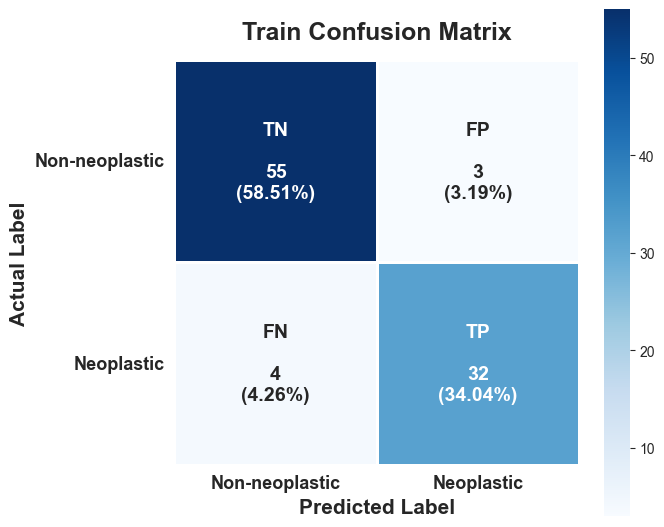

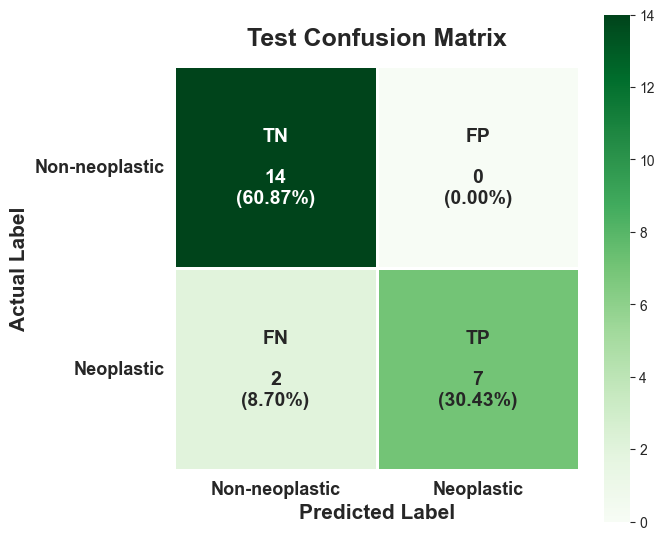

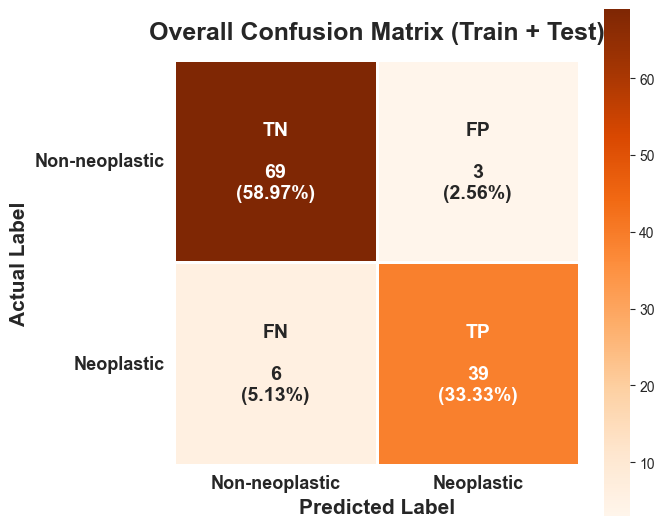

In [201]:
# ==========================================================
# Cell 13 : Attractive Confusion Matrices
# ==========================================================

CLASS_NAMES = [

    "Non-neoplastic",

    "Neoplastic"

]

###########################################################
# Train
###########################################################

plot_confusion_matrix(

    best_train_labels,

    best_train_predictions,

    CLASS_NAMES,

    title="Train Confusion Matrix",

    cmap="Blues"

)

###########################################################
# Test
###########################################################

plot_confusion_matrix(

    best_test_labels,

    best_test_predictions,

    CLASS_NAMES,

    title="Test Confusion Matrix",

    cmap="Greens"

)

###########################################################
# Overall (Train + Test)
###########################################################

overall_labels = np.concatenate(

    [

        best_train_labels,

        best_test_labels

    ]

)

overall_predictions = np.concatenate(

    [

        best_train_predictions,

        best_test_predictions

    ]

)

plot_confusion_matrix(

    overall_labels,

    overall_predictions,

    CLASS_NAMES,

    title="Overall Confusion Matrix (Train + Test)",

    cmap="Oranges"

)

# 14. Train & Test Loss Curve : 

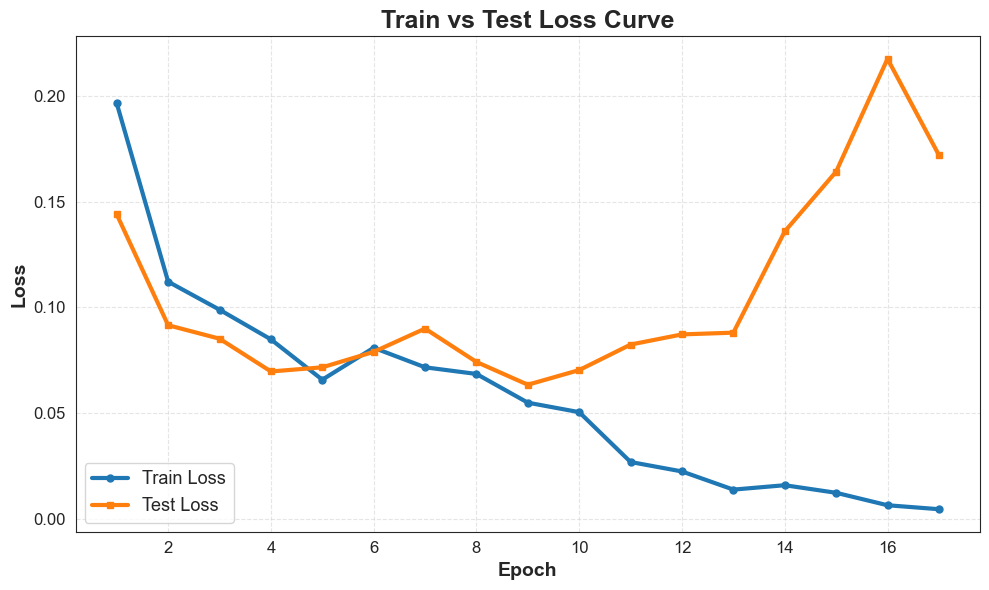

In [202]:
# ==========================================================
# Cell 14 : Train & Test Loss Curve
# ==========================================================

import matplotlib.pyplot as plt

epochs = range(1, len(best_train_loss_history) + 1)
plt.figure(figsize=(10,6))
plt.plot(
    epochs,
    best_train_loss_history,
    linewidth=3,
    marker="o",
    markersize=5,
    label="Train Loss"
)

plt.plot(
    epochs,
    best_test_loss_history,
    linewidth=3,
    marker="s",
    markersize=5,
    label="Test Loss"
)

plt.title(
    "Train vs Test Loss Curve",
    fontsize=18,
    fontweight="bold"

)

plt.xlabel(
    "Epoch",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontsize=14,
    fontweight="bold"

)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend(
    fontsize=13,
    loc="best"
)

plt.tight_layout()
plt.show()

# 15. Train Test Accuracy Curve : 

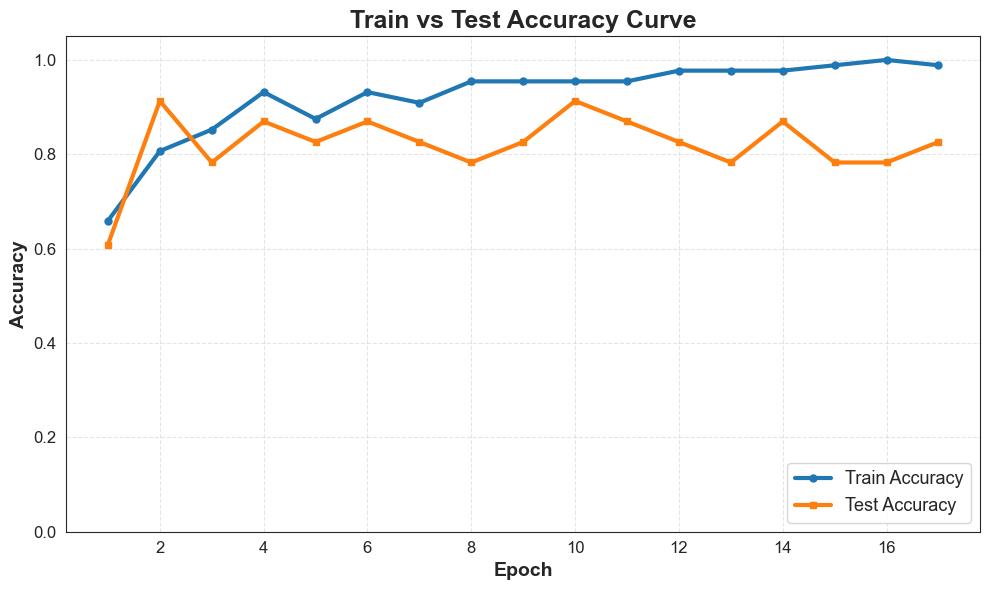

In [203]:
# ==========================================================
# Cell 15 : Train & Test Accuracy Curve
# ==========================================================

import matplotlib.pyplot as plt

epochs = range(1, len(best_train_acc_history) + 1)
plt.figure(figsize=(10,6))
plt.plot(
    epochs,
    best_train_acc_history,
    linewidth=3,
    marker="o",
    markersize=5,
    label="Train Accuracy"
)

plt.plot(
    epochs,
    best_test_acc_history,
    linewidth=3,
    marker="s",
    markersize=5,
    label="Test Accuracy"
)

plt.title(
    "Train vs Test Accuracy Curve",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Epoch",
    fontsize=14,
    fontweight="bold"

)

plt.ylabel(
    "Accuracy",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend(
    fontsize=13,
    loc="lower right"

)

plt.tight_layout()
plt.show()

# 16. Sensitivity & Specificity (Train and Test) for Each Class : 

In [204]:
# ==========================================================
# Cell 16 : Sensitivity & Specificity
# ==========================================================

from sklearn.metrics import confusion_matrix

CLASS_NAMES = [
    "Non-neoplastic",
    "Neoplastic"
]

############################################################
# Function
############################################################

def calculate_sensitivity_specificity(y_true, y_pred) :
    cm = confusion_matrix(y_true, y_pred)
    sensitivity = []
    specificity = []

    for i in range(len(cm)) :
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        sen = TP / (TP + FN) if (TP + FN) != 0 else 0
        spe = TN / (TN + FP) if (TN + FP) != 0 else 0
        sensitivity.append(sen)
        specificity.append(spe)

    return sensitivity, specificity

############################################################
# Train
############################################################

train_sensitivity, train_specificity = calculate_sensitivity_specificity(
    best_train_labels,
    best_train_predictions
)

############################################################
# Test
############################################################

test_sensitivity, test_specificity = calculate_sensitivity_specificity(
    best_test_labels,
    best_test_predictions
)

############################################################
# Print Results
############################################################

print("=" * 80)
print("TRAIN SENSITIVITY & SPECIFICITY")
print("=" * 80)

for i, cls in enumerate(CLASS_NAMES) :
    print(f"\n{cls}")
    print(f"Sensitivity : {train_sensitivity[i]:.4f}")
    print(f"Specificity : {train_specificity[i]:.4f}")

print("\n")

print("=" * 80)
print("TEST SENSITIVITY & SPECIFICITY")
print("=" * 80)

for i, cls in enumerate(CLASS_NAMES) :
    print(f"\n{cls}")
    print(f"Sensitivity : {test_sensitivity[i]:.4f}")
    print(f"Specificity : {test_specificity[i]:.4f}")

TRAIN SENSITIVITY & SPECIFICITY

Non-neoplastic
Sensitivity : 0.9483
Specificity : 0.8889

Neoplastic
Sensitivity : 0.8889
Specificity : 0.9483


TEST SENSITIVITY & SPECIFICITY

Non-neoplastic
Sensitivity : 1.0000
Specificity : 0.7778

Neoplastic
Sensitivity : 0.7778
Specificity : 1.0000


# 17. Expected Calibration Error (ECE Score) : 

In [207]:
# ==========================================================
# Cell 17 : Expected Calibration Error (ECE)
# ==========================================================

import numpy as np

############################################################
# Function to Compute ECE
############################################################

def compute_ece(y_true, y_prob, n_bins=10) :
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins) :
        lower = bins[i]
        upper = bins[i + 1]

        if i == n_bins - 1 :
            mask = (y_prob >= lower) & (y_prob <= upper)

        else :
            mask = (y_prob >= lower) & (y_prob < upper)

        if np.sum(mask) == 0 :
            continue

        accuracy = np.mean(y_true[mask] == (y_prob[mask] >= 0.5))
        confidence = np.mean(y_prob[mask])
        ece += np.abs(accuracy - confidence) * (np.sum(mask) / len(y_true))

    return ece

############################################################
# Train ECE
############################################################

train_ece = compute_ece(
    best_train_labels,
    best_train_probabilities,
    n_bins=10

)

############################################################
# Test ECE
############################################################

test_ece = compute_ece(
    best_test_labels,
    best_test_probabilities,
    n_bins=10

)

############################################################
# Print Results
############################################################

print("=" * 70)
print("EXPECTED CALIBRATION ERROR (ECE)")
print("=" * 70)

print(f"\nTrain ECE : {train_ece:.4f}")
print(f"Test ECE  : {test_ece:.4f}")

EXPECTED CALIBRATION ERROR (ECE)

Train ECE : 0.5089
Test ECE  : 0.4806


# 18. Brier Score (Train & Test) : 

In [208]:
# ==========================================================
# Cell 18 : Brier Score
# ==========================================================

from sklearn.metrics import brier_score_loss

############################################################
# Train Brier Score
############################################################

train_brier = brier_score_loss(
    best_train_labels,
    best_train_probabilities

)

############################################################
# Test Brier Score
############################################################

test_brier = brier_score_loss(
    best_test_labels,
    best_test_probabilities

)

############################################################
# Print Results
############################################################

print("=" * 70)
print("BRIER SCORE")
print("=" * 70)

print(f"\nTrain Brier Score : {train_brier:.4f}")
print(f"Test Brier Score  : {test_brier:.4f}")

BRIER SCORE

Train Brier Score : 0.1327
Test Brier Score  : 0.1529


# 19. ROC-AUC Score (Train & Test) : 

In [209]:
# ==========================================================
# Cell 19 : ROC-AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

############################################################
# Train ROC-AUC
############################################################

train_auc = roc_auc_score(
    best_train_labels,
    best_train_probabilities

)

############################################################
# Test ROC-AUC
############################################################

test_auc = roc_auc_score(
    best_test_labels,
    best_test_probabilities

)

############################################################
# Print Results
############################################################

print("=" * 70)
print("ROC-AUC SCORE")
print("=" * 70)

print(f"\nTrain ROC-AUC Score : {train_auc:.4f}")
print(f"Test ROC-AUC Score  : {test_auc:.4f}")

ROC-AUC SCORE

Train ROC-AUC Score : 0.9607
Test ROC-AUC Score  : 0.9921


# 20. ROC-AUC Curve : 

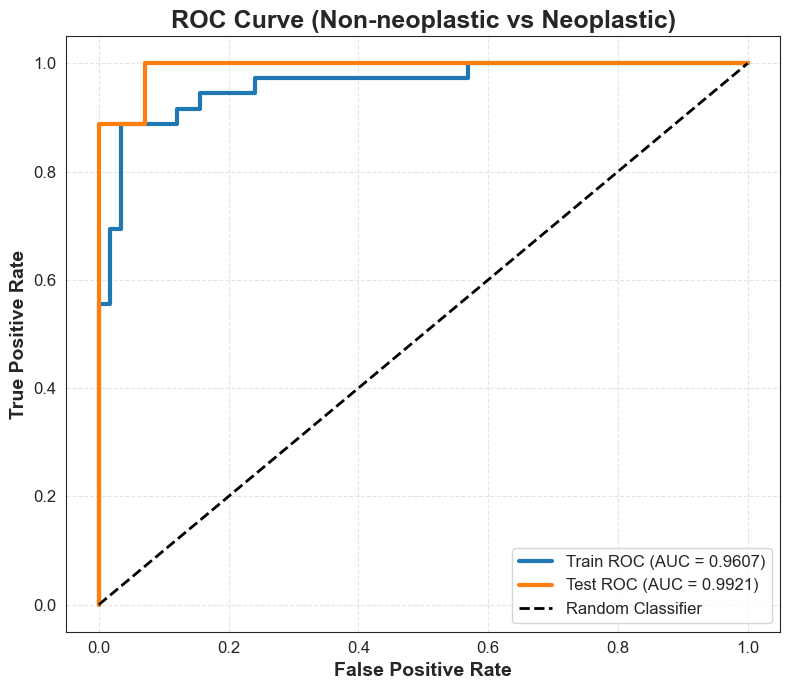

In [210]:
# ==========================================================
# Cell 20 : ROC-AUC Curve
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

############################################################
# Train ROC
############################################################

train_fpr, train_tpr, _ = roc_curve(

    best_train_labels,

    best_train_probabilities

)

train_auc = roc_auc_score(

    best_train_labels,

    best_train_probabilities

)

############################################################
# Test ROC
############################################################

test_fpr, test_tpr, _ = roc_curve(

    best_test_labels,

    best_test_probabilities

)

test_auc = roc_auc_score(

    best_test_labels,

    best_test_probabilities

)

############################################################
# Plot
############################################################

plt.figure(figsize=(8,7))

plt.plot(

    train_fpr,

    train_tpr,

    linewidth=3,

    label=f"Train ROC (AUC = {train_auc:.4f})"

)

plt.plot(

    test_fpr,

    test_tpr,

    linewidth=3,

    label=f"Test ROC (AUC = {test_auc:.4f})"

)

############################################################
# Random Classifier
############################################################

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    linewidth=2,

    color="black",

    label="Random Classifier"

)

############################################################
# Labels
############################################################

plt.title(

    "ROC Curve (Non-neoplastic vs Neoplastic)",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "False Positive Rate",

    fontsize=14,

    fontweight="bold"

)

plt.ylabel(

    "True Positive Rate",

    fontsize=14,

    fontweight="bold"

)

plt.xticks(fontsize=12)

plt.yticks(fontsize=12)

plt.grid(

    linestyle="--",

    alpha=0.5

)

plt.legend(

    fontsize=12,

    loc="lower right"

)

plt.tight_layout()

plt.show()

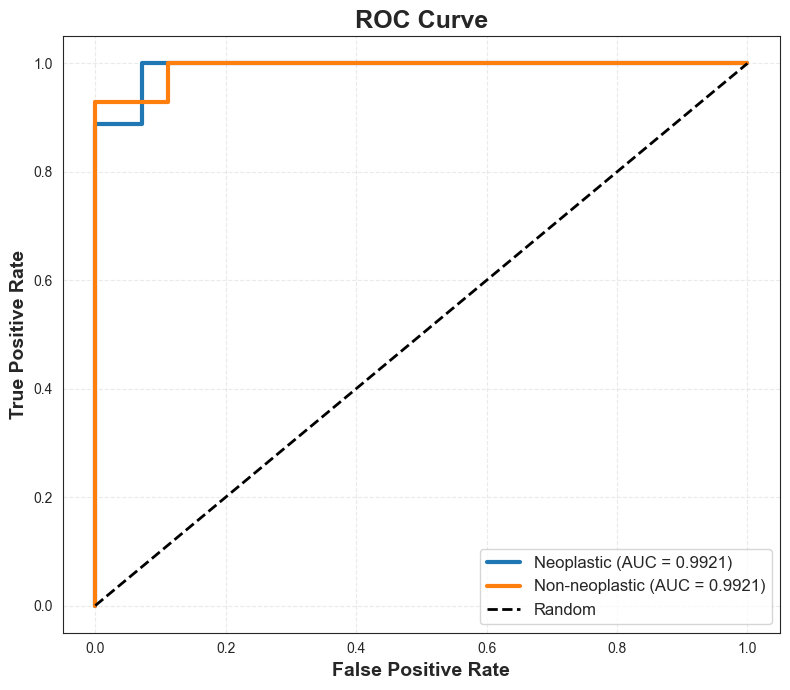

In [211]:
# ==========================================================
# Cell 20 : ROC Curve for Both Classes
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

############################################################
# Neoplastic (Positive Class = 1)
############################################################

fpr_neo, tpr_neo, _ = roc_curve(

    best_test_labels,

    best_test_probabilities,

    pos_label=1

)

auc_neo = roc_auc_score(

    best_test_labels,

    best_test_probabilities

)

############################################################
# Non-neoplastic (Positive Class = 0)
############################################################

non_labels = 1 - np.array(best_test_labels)

non_prob = 1 - np.array(best_test_probabilities)

fpr_non, tpr_non, _ = roc_curve(

    non_labels,

    non_prob,

    pos_label=1

)

auc_non = roc_auc_score(

    non_labels,

    non_prob

)

############################################################
# Plot
############################################################

plt.figure(figsize=(8,7))

plt.plot(

    fpr_neo,

    tpr_neo,

    linewidth=3,

    label=f"Neoplastic (AUC = {auc_neo:.4f})"

)

plt.plot(

    fpr_non,

    tpr_non,

    linewidth=3,

    label=f"Non-neoplastic (AUC = {auc_non:.4f})"

)

############################################################

plt.plot(

    [0,1],

    [0,1],

    'k--',

    linewidth=2,

    label="Random"

)

############################################################

plt.title(

    "ROC Curve",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "False Positive Rate",

    fontsize=14,

    fontweight="bold"

)

plt.ylabel(

    "True Positive Rate",

    fontsize=14,

    fontweight="bold"

)

plt.grid(

    linestyle="--",

    alpha=0.4

)

plt.legend(

    fontsize=12,

    loc="lower right"

)

plt.tight_layout()

plt.show()

# 21. Final Results Summary Table : 

In [212]:
# ==========================================================
# Cell 21 : Final Summary Results Dataset
# ==========================================================

import pandas as pd

############################################################
# Create Final Summary Table
############################################################

summary_results = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1",
        "ROC-AUC",
        "ECE",
        "Brier Score"

    ],

    "Train": [

        avg_train_accuracy,
        avg_train_precision,
        avg_train_recall,
        avg_train_f1,
        train_auc,
        train_ece,
        train_brier

    ],

    "Test": [

        avg_test_accuracy,
        avg_test_precision,
        avg_test_recall,
        avg_test_f1,
        test_auc,
        test_ece,
        test_brier

    ]

})

############################################################
# Display
############################################################

print("=" * 80)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 80)

print(summary_results)

############################################################
# Optional : Save CSV
############################################################

summary_results.to_csv(

    "Final_Summary_Results.csv",

    index=False

)

print("\nResults saved as : Final_Summary_Results.csv")

FINAL PERFORMANCE SUMMARY
        Metric     Train      Test
0     Accuracy  0.925532  0.913043
1    Precision  0.923245  0.937500
2       Recall  0.918582  0.888889
3     Macro F1  0.920790  0.904167
4      ROC-AUC  0.960728  0.992063
5          ECE  0.508882  0.480591
6  Brier Score  0.132705  0.152851

Results saved as : Final_Summary_Results.csv
